In [1]:
#!/usr/bin/env python2
# -*- coding: utf-8 -*-
"""
This script shows an example for how to make 2D plots of the
column model solution, using the interpolation tools
"""

import sys
sys.path.append('../Modules')
from pymoc.modules import Psi_Thermwind, Psi_SO
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

plt.close('all')

Diag=np.load('diags.npz')

# Notice that some of these variables may need to be adjusted to match the
# simulations to be plotted:
L=2e7
l=2e6;
nb=500
b_basin=1.0*Diag['arr_2'][:,-1];
b_north=1.0*Diag['arr_3'][:,-1];
bs_SO=1.0*Diag['arr_4'][:,-1];
z=1.0*Diag['arr_5'];
y=1.0*Diag['arr_7'];
tau=1.0*Diag['arr_9'];
kapGM=1.0*Diag['arr_10'];

AMOC = Psi_Thermwind(z=z,b1=b_basin,b2=b_north,f=1.2e-4)
AMOC.solve()
PsiSO=Psi_SO(z=z,y=y,b=b_basin,bs=bs_SO,tau=tau,f=1.2e-4,L=L,KGM=kapGM)
PsiSO.solve()

blevs=np.arange(-0.01,0.03,0.001) 
plevs=np.arange(-28.,28.,2.0)

bs=1.*bs_SO;bn=1.*b_basin;

if bs[0]>bs[1]:
   # due to the way the time-stepping works bs[0] can be infinitesimally larger 
   # than bs[0] here, which messe up interpolation 
   bs[0]=bs[1]
if bs[0]<bn[0]:
   # Notice that bn[0] can at most be infinitesimally larger than bs[0] 
   # (since bottom water formation from the channel should be happening in this case)
   # but for the interpolation to work, we need it infinitesimally smaller than bs[0]  
   bn[0]=bs[0]; 

# first interpolate buoyancy in channel along constant-slope isopycnals: 
bint=Interpolate_channel(y=y,z=z,bs=bs,bn=bn)
bsouth=bint.gridit()
# buoyancy in the basin is all the same:
lbasin=12000.
lnorth=1000.
lchannel=l/1e3
ybasin=np.linspace(lbasin/60.,lbasin,60)+lchannel;
bbasin=np.tile(b_basin,(len(ybasin),1))
# finally, interpolate buoyancy in the north:
ynorth=np.linspace(lnorth/10.,lnorth,10)+lchannel+lbasin;
bn=b_north.copy();
bn[0]=b_basin[0];# Notice that the interpolation procedure assumes that the bottom
#buoyancies in both colums match - which may not be exactly the case depending
# on when in teh time-step data is saved 
bint=Interpolate_twocol(y=ynorth*1000.-ynorth[0]*1000.,z=z,bs=b_basin,bn=bn)
bnorth=bint.gridit()
# now stick it all together:
ynew=np.concatenate((y/1e3,ybasin,ynorth))
bnew=np.concatenate((bsouth,bbasin,bnorth))

# Compute z-coordinate, b-coordinate and residual overturning streamfunction at all latitudes:
psiarray_b=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_res=np.zeros((len(ynew),len(z))) # "residual" overturning - i.e. isopycnal overturning mapped into z space
psiarray_z=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning
for iy in range(1,len(y)):
    # in the channel, interpolate PsiSO.Psi onto local isopycnal depth:
    psiarray_res[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO.Psi)
    psiarray_z[iy,:]=psiarray_res[iy,:]
    psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO.Psi[b_basin<bs_SO[iy]]
for iy in range(len(y),len(y)+len(ybasin)):
    # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
    psiarray_res[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*PsiSO.Psi)/lbasin   
    psiarray_z[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*PsiSO.Psi)/lbasin  
    psiarray_b[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*PsiSO.Psi)/lbasin  
for iy in range(len(y)+len(ybasin),len(ynew)):
    # in the north, interpolate AMOC.psib to local isopycnal depth:
    psiarray_res[iy,:]=np.interp(bnew[iy,:],AMOC.bgrid,AMOC.Psib(nb=nb))
    psiarray_z[iy,:]=((lchannel+lbasin+lnorth-ynew[iy])*AMOC.Psi)/lnorth      
    psiarray_b[iy,b_basin<bnew[iy,-1]]=AMOC.Psibz(nb=nb)[0][b_basin<bnew[iy,-1]]      
psiarray_res[-1,:]=0.;


# plot z-coord. overturning:
fig = plt.figure(figsize=(7,4))
ax1 = fig.add_subplot(111)
CS=ax1.contour(ynew,z,bnew.transpose(),levels=blevs,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10)
ax1.contour(ynew,z,psiarray_z.transpose(),levels=plevs,colors='0.5',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-max(plevs), vmax=max(plevs))
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Depth-averaged Overturning',fontsize=12)
fig.colorbar(CS, ticks=plevs[0::5], orientation='vertical')
fig.tight_layout()   
#fig.savefig('psi_b_2D_depth.png', format='png', dpi=600)

# plot b-coord. overturning:
fig = plt.figure(figsize=(7,4))
ax1 = fig.add_subplot(111)
CS=ax1.contourf(ynew,z,psiarray_b.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-max(plevs), vmax=max(plevs))
ax1.contour(ynew,z,psiarray_b.transpose(),levels=plevs,colors='0.5',linewidths=0.5)
ax1.set_xlim([0,ynew[-1]])
#ax1.plot(ynew,np.interp(bnew[:,-1],b_basin,z),'k',linewidth=1,colors='0.5')
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005, 0., -0.001 , -0.002, -0.003],b_basin,z))
ax1.set_yticklabels([0.02, 0.005, 0., -0.001 , -0.002, -0.003])
ax1.set_title('Isopycnal Overturning',fontsize=12)
fig.colorbar(CS, ticks=plevs[0::5], orientation='vertical')
fig.tight_layout()  
#fig.savefig('psi_b_2D_iso.png', format='png', dpi=600)
       

# Plot profiles:
fig = plt.figure(figsize=(4,4))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4.5e3,0))
ax1.set_ylabel('Depth [m]', fontsize=13)
ax1.set_xlim((-28,28))
ax2.set_xlim((-0.028,0.028))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC.Psi, AMOC.z,linewidth=2,color='m',linestyle='--',label='$\Psi_N$')
ax1.plot(PsiSO.Psi, PsiSO.z,linewidth=2,color='c',linestyle='--',label='$\Psi_{SO}$')
ax2.plot(b_north, z, linewidth=2,color='r',label='$b_N$')
ax2.plot(b_basin, z, linewidth=2,color='b',label='$b_B$')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')
fig.tight_layout()
#fig.savefig('profiles.png', format='png', dpi=600)

plt.show()


NameError: name 'intez' is not defined

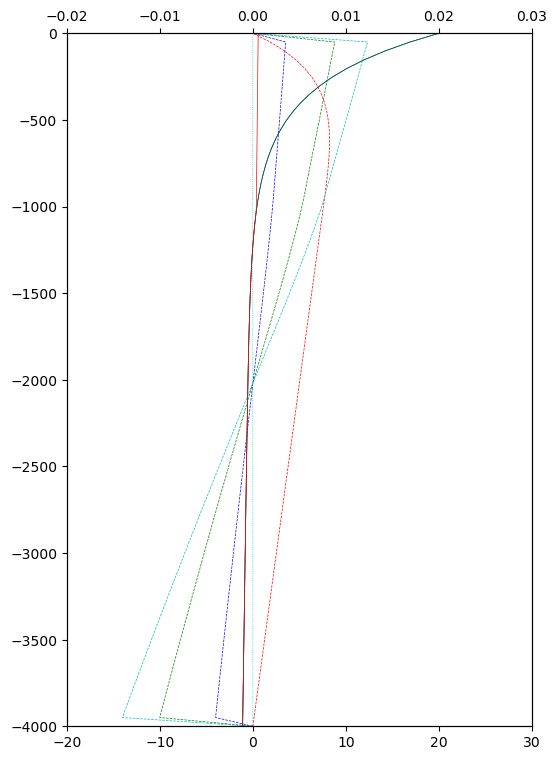

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/2027147337.py:321: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/2027147337.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


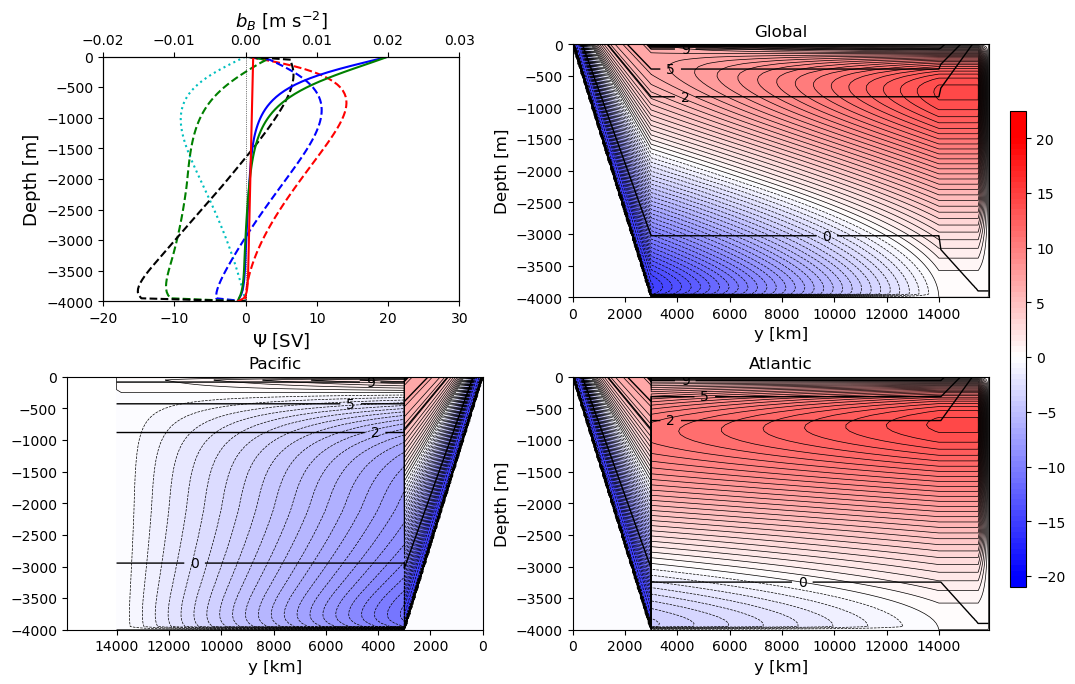

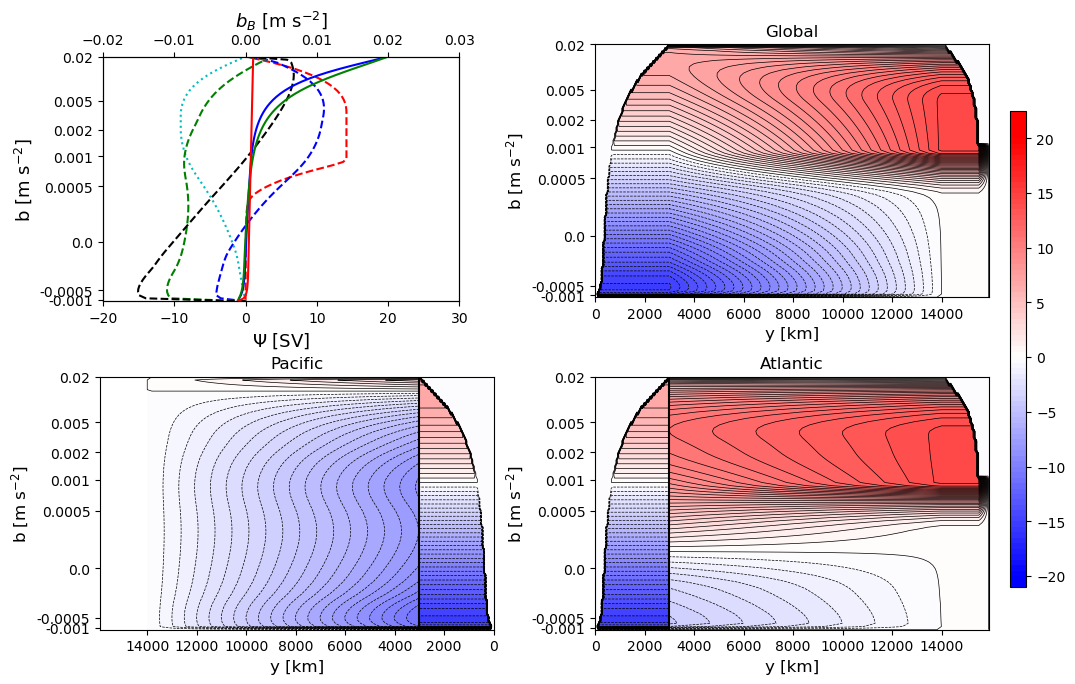

In [3]:
'''
This script shows an example of a three column model for the 
overturning circulation in two basins connected to a channel in the south.
Two columns represent the two basins, while the third column represents
the northern sinking region, connected to one of the basins (teh "Atlantic").
The meridional overtunning circulation is computed at the northern end of the
first basin (i.e at the interface to the northern sinking region), and at the 
the southern end of each basin (i.e. at the interface to the channel). 
Moreover, a zonal overturning circulation between the two basins in the channel
is computed (using the thermal wind relation - analog to the computation of the 
overturning between the basin and the northern sinking region).
Adiabatic mapping is used for the overturning between the differn columns
'''

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file=None

# boundary conditions:
bs=0.02;
# the minimum surface buoyancy in the GCM in the North Atlantic is 3.5890e-04 (or 0.1795C)
bs_north=0.00036; bAABW=-0.0011; bbot=min(bAABW,bs_north)

# S.O. surface boundary conditions and grid:
y=np.asarray(np.linspace(0,3.e6, 51))
tau=0.16
offset=0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6));
bs_SO=(0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
      +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5));

# time-stepping parameters:
dt=86400.*30.                               # time-step for vert. adv. diff. calc.
MOC_up_iters=int(np.floor(2.*360*86400/dt)) # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
plot_iters= int(np.ceil(500*360*86400/dt))  # plotting frequency (in iterations)
total_iters=int(np.ceil(4000*360*86400/dt))# total number of timesteps

# Effective diffusivity profile
def kappaeff(z): # effective diffusivity profile with tapering in BBL
        return 1.0*( 1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000. + np.minimum(z+2000.,0)/1300.))
                *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2 )

A_Atl=7e13#6e13  
A_north=5.5e12
A_Pac=1.7e14#1.44e14

Lx = 1.3e+07  #(length of the channel)
Latl=6./21.*Lx;
Lpac=15./21.*Lx;
K = 1800.
N2min=2e-7

# create vertical grid:
z=np.asarray(np.linspace(-4000, 0, 80))

# create initial guess for buoyancy profile in the Atl
def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
#def b_Atl(z): return 0.3*bs+z/z[0]*(bbot-0.3*bs)
def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

# create N.A. overturning model instance
AMOC = Psi_Thermwind(z=z,b1=b_Atl,b2=0.01*b_Atl(z))
# and solve for initial overturning streamfunction:
AMOC.solve()
# map North Atlantic overturning to isopycnal space:
[Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

# create interbasin zonal overturning model instance
ZOC = Psi_Thermwind(z=z,b1=b_Atl,b2=b_Pac, f=1e-4)
# and solve for initial overturning streamfunction:
ZOC.solve()
# map inter-basin overturning to isopycnal space:
[Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

# create S.O. overturning model instance for Atlantic sector
SO_Atl=Psi_SO(z=z,y=y,b=b_Atl(z),bs=bs_SO,tau=tau,L=Latl,KGM=K)
SO_Atl.solve()

# create S.O. overturning model instance for Pacific sector
SO_Pac=Psi_SO(z=z,y=y,b=b_Pac(z),bs=bs_SO,tau=tau,L=Lpac,KGM=K)
SO_Pac.solve()

# create adv-diff column model instance for Atl
Atl= Column(z=z,kappa=kappaeff,b=b_Atl,bs=bs,bbot=bbot,Area=A_Atl,N2min=N2min)
# create adv-diff column model instance for northern sinking region
north= Column(z=z,kappa=kappaeff,b=b_Atl,bs=bs_north,bbot=bbot,Area=A_north,N2min=N2min)
# create adv-diff column model instance for Pac
Pac= Column(z=z,kappa=kappaeff,b=b_Pac,bs=bs,bbot=bbot,Area=A_Pac,N2min=N2min)

# Create figure:
fig = plt.figure(figsize=(6,9))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))

# loop to iteratively find equilibrium solution
for ii in range(0, total_iters):    
   # update buoyancy profile
   # using isopycnal overturning:
   wA_Atl=(Psi_iso_Atl+Psi_zonal_Atl-SO_Atl.Psi)*1e6
   wAN=-Psi_iso_N*1e6
   wA_Pac=(-Psi_zonal_Pac-SO_Pac.Psi)*1e6
   Atl.timestep(wA=wA_Atl,dt=dt)
   north.timestep(wA=wAN,dt=dt,do_conv=True)
   Pac.timestep(wA=wA_Pac,dt=dt)
   
   if ii%MOC_up_iters==0:
      # update overturning streamfunction (can be done less frequently)
      AMOC.update(b1=Atl.b,b2=north.b)
      AMOC.solve()
      [Psi_iso_Atl, Psi_iso_N]=AMOC.Psibz()
      ZOC.update(b1=Atl.b,b2=Pac.b)
      ZOC.solve()
      [Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()
      SO_Atl.update(b=Atl.b)
      SO_Atl.solve()
      SO_Pac.update(b=Pac.b)
      SO_Pac.solve()
     
   if ii%plot_iters==0:
      # Plot current state:
      ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=0.5)
      ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=0.5)
      ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=0.5)
      ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=0.5)
      ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=0.5)
      ax2.plot(Atl.b, Atl.z, '-b', linewidth=0.5)
      ax2.plot(Pac.b, Pac.z, '-g', linewidth=0.5)
      ax2.plot(north.b, north.z, '-r', linewidth=0.5)
      plt.pause(0.01)
      print  ("t=",round(ii*dt/86400/360),"years")
 
ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--c', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)

# Write out diagnostics (if diag file name is provided):
if diag_file is not None:
   np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b,
            Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
            Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
            Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid)

#*****************************************************************************
# Below is all just for fancy plots
#*****************************************************************************

blevs=np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
#plevs=np.arange(-21.,23.,2.0)
plevs=np.arange(-21.,23.,0.5)

nb=500;

b_basin=(A_Atl*Atl.b+A_Pac*Pac.b)/(A_Atl+A_Pac);
b_north=north.b;

# Compute total SO residual overturning by first interpolating circulation 
# in both sectors to mean buoyancy profile values and then summing (at constant b).
PsiSO=(np.interp(b_basin,Atl.b,SO_Atl.Psi)
      +np.interp(b_basin,Pac.b,SO_Pac.Psi));
AMOC_bbasin=np.interp(b_basin,AMOC.bgrid,AMOC.Psib(nb=nb));
# this is to Plot adiabatic overturning only:
PsiSO_bgrid=(np.interp(AMOC.bgrid,Atl.b,SO_Atl.Psi)
            +np.interp(AMOC.bgrid,Pac.b,SO_Pac.Psi));

l=y[-1];

bs=1.*bs_SO;bn=1.*b_basin;
bs[-1]=1.*bn[-1]; # if bs is tiny bit warmer there is a zero slope point at the surface which makes the interpolation fail...

# first interpolate buoyancy in channel along constant-slope isopycnals: 
bint=Interpolate_channel(y=y,z=z,bs=bs,bn=bn)
bsouth=bint.gridit()
# buoyancy in the basin is all the same:
lbasin=11000.
ltrans=1500.
lnorth=400.
lchannel=l/1e3
ybasin=np.linspace(0,lbasin,60)+lchannel;
bbasin=np.tile(b_basin,(len(ybasin),1))
bAtl=np.tile(Atl.b,(len(ybasin),1))
bPac=np.tile(Pac.b,(len(ybasin),1))
# interpolate buoyancy in northern ransition region:
ytrans=np.linspace(ltrans/20.,ltrans,20)+lchannel+lbasin;
bn=b_north.copy();
bn[0]=b_basin[0];# Notice that the interpolation procedure assumes that the bottom
#buoyancies in both colums match - which may not be exactly the case depending
# on when in teh time-step data is saved 
bint=Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000.,z=z,bs=Atl.b,bn=bn)
btrans=bint.gridit()
# finally set buyancy in northern deep water formation region:
ynorth=np.linspace(lnorth/20.,lnorth,20)+lchannel+lbasin+ltrans;
bnorth=np.tile(bn,(len(ynorth),1))
# now stick it all together:
ynew=np.concatenate((y/1e3,ybasin,ytrans,ynorth))
bnew=np.concatenate((bsouth,bbasin,btrans,bnorth))
bnew_Atl=np.concatenate((bsouth,bAtl,btrans,bnorth))
bnew_Pac=np.concatenate((bsouth,bPac,np.nan*btrans,np.nan*bnorth))

# Compute z-coordinate and residual overturning streamfunction at all latitudes:
psiarray_b=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_b_Atl=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_b_Pac=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_Atl=np.zeros((len(ynew),len(z))) # "residual" overturning in ATl.
psiarray_Pac=np.zeros((len(ynew),len(z))) # "residual" overturning in Pac.
psiarray_z=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning
psiarray_z_Atl=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning
psiarray_z_Pac=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning

for iy in range(1,len(y)):
    # in the channel, interpolate PsiSO onto local isopycnal depth:
    psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
    psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
    psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
    psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO);    
    psiarray_b_Atl[iy,:]=psiarray_b[iy,:];    
    psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)   
    psiarray_b_Pac[iy,:]=psiarray_b[iy,:];    

    
for iy in range(len(y),len(y)+len(ybasin)):
    # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
    psiarray_z[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi+SO_Pac.Psi))/lbasin  
    psiarray_z_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psi))/lbasin  
    psiarray_z_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psi))/lbasin  
    psiarray_b[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin
                      +(lchannel+lbasin-ynew[iy])*PsiSO)/lbasin  
    
    psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin   
    psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin+
                    (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi)
                      -np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin   
    psiarray_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[1]))/lbasin   
    psiarray_b_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi)
                        +np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin  

    
for iy in range(len(y)+len(ybasin),len(y)+len(ybasin)+len(ytrans)):
    # in the northern transition region keep psi_z constant 
    # and psi_b constant on non-outcropped isopycnals (but zero on outcropped
    # isopycnals):
    psiarray_z[iy,:]=AMOC.Psi      
    psiarray_z_Atl[iy,:]=AMOC.Psi      
    psiarray_z_Pac[iy,:]=np.nan      
    psiarray_b[iy,b_basin<bnew[iy,-1]]=AMOC_bbasin[b_basin<bnew[iy,-1]]      
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],AMOC.bgrid,AMOC.Psib(nb=nb))
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan

    
for iy in range(len(y)+len(ybasin)+len(ytrans),len(ynew)):
    # in the northern sinking region, all psi decrease linearly to zero:
    psiarray_z[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth      
    psiarray_z_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth      
    psiarray_z_Pac[iy,:]=np.nan     
    psiarray_b[iy,b_basin<bnew[iy,-1]]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])
        *AMOC_bbasin[b_basin<bnew[iy,-1]])/lnorth      
    psiarray_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psibz(nb=nb)[1])/lnorth
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan

# plot z-coordinate overturning and buoyancy structure:
    
fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('Depth [m]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)     
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')

ax1 = fig.add_subplot(222)
CS=ax1.contour(ynew,z,bnew.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Global',fontsize=12)
       
ax1 = fig.add_subplot(223)
CS=ax1.contour(ynew,z,bnew_Pac.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
CS=ax1.contour(ynew,z,bnew_Atl.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()   
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')

# Plot Isopycnal overturning

fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
ax1.plot(np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, ':c', linewidth=1.5)
ax1.plot(np.interp(b_basin,Atl.b,SO_Atl.Psi)
        -np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--b', linewidth=1.5)
ax1.plot(np.interp(b_basin,Pac.b,SO_Pac.Psi)
          +np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--g', linewidth=1.5)
ax1.plot(PsiSO, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)     
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

ax1 = fig.add_subplot(222)
ax1.contour(ynew,z,psiarray_b.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Global',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
       
ax1 = fig.add_subplot(223)
ax1.contour(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
ax1.contour(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()   
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')


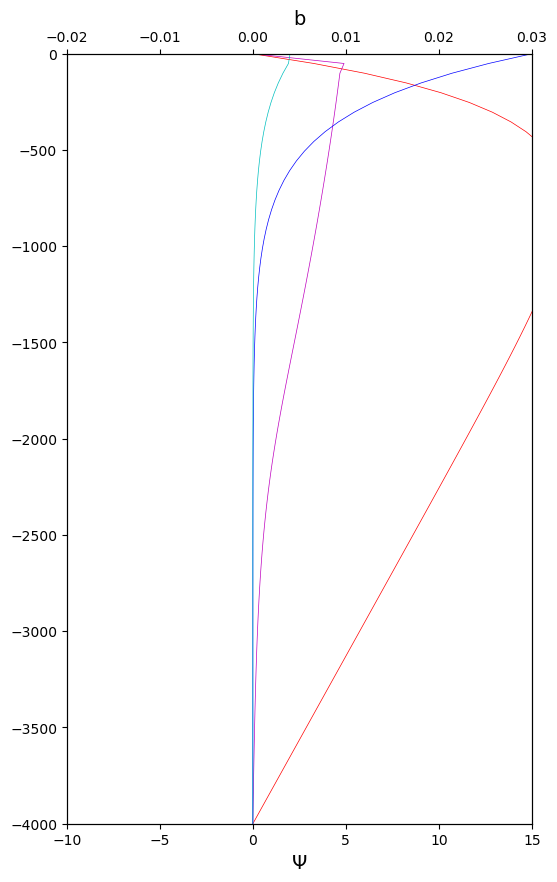

Text(0.5, 1.0, 'Depth-averaged Overturning')

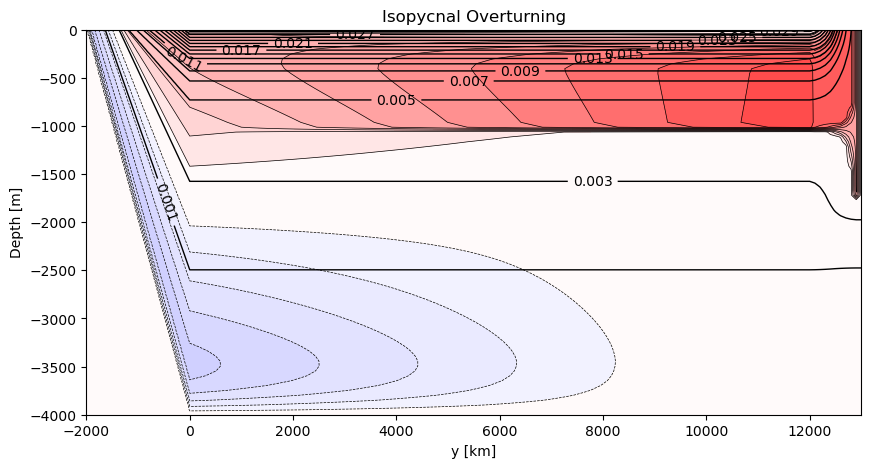

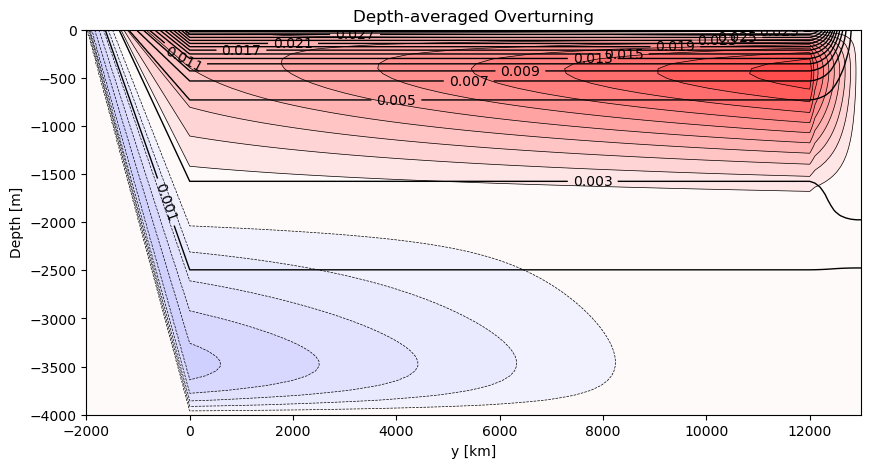

In [4]:
'''
This script shows an example of a "two column" model for the 
overturning circulation in a basin connected to a channel in the south.
The first column represents the basin, while the second column represents
the northern sinking region. The overtunning circulation is computed at
the northern end of the basin (at the interface to the northern sinking region)
and at the southern end of the basin (at the interface to the channel).
The parameters chosen here follow more or less the "control" experiment of Nikurashin
and Vallis (2012, JPO).
'''
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

# boundary conditions:
bs = 0.03
bs_north = 0.004
bmin = 0.0

# S.O. surface boundary conditions and grid:
l = 2.e6
y = np.asarray(np.linspace(0, l, 40))
#Although the model can emulate the effect of a meridionally varying wind-stress,
# that feature is in "beta" and we are here for simplicity using a constant
# wind-stress (approximately the average over the channel in NV12):
tau = 0.13
# from what I can infer, NV12 use an approximately quadratic surface temperature
# profile in the channel for their SAMBUCA simulations:
bs_SO = (bs-bmin) * (y / y[-1])**2 + bmin

A_basin = 6e13    #area of the basin
A_north = A_basin / 50.    #area of northern sinking region

# time-stepping parameters:
dt = 86400 * 30    # time-step for vert. adv. diff. calc.
MOC_up_iters = int(
    np.floor(2. * 360 * 86400 / dt)
)    # multiplier for MOC time-step (MOC is updated every MOC_up_iters time steps)
plot_iters = int(
    np.ceil(300 * 360 * 86400 / dt)
)    # plotting frequency (in iterations)
total_iters = int(
    np.ceil(3000 * 360 * 86400 / dt)
)    # total number of timesteps

kappa = 2e-5

# create vertical grid:
z = np.asarray(np.linspace(-4000, 0, 80))


# Initial conditions for buoyancy profile in the basin
def b_basin(z):
  return bs * np.exp(z / 300.)
def b_north(z):
  return bs_north * np.exp(z / 300.)


# create N.A. overturning model instance
AMOC = Psi_Thermwind(z=z, b1=b_basin, b2=b_north, f=1e-4)
# and solve for initial overturning streamfunction:
AMOC.solve()
# evaluate overturning in isopycnal space:
[Psi_iso_b, Psi_iso_n] = AMOC.Psibz()

# create S.O. overturning model instance
SO = Psi_SO(
    z=z,
    y=y,
    b=b_basin(z),
    bs=bs_SO,
    tau=tau,
    f=1e-4,
    L=5e6,
    KGM=1000.,
    c=0.1,
    bvp_with_Ek=True
)
SO.solve()

# create adv-diff column model instance for basin
basin = Column(z=z, kappa=kappa, Area=A_basin, b=b_basin, bs=bs, bbot=bmin)
# create adv-diff column model instance for basin
north = Column(z=z, kappa=kappa, Area=A_north, b=b_north, bs=bs_north, bbot=bmin)

# Create figure:
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-10, 15))
ax2.set_xlim((-0.02, 0.03))
ax1.set_xlabel('$\Psi$', fontsize=14)
ax2.set_xlabel('b', fontsize=14)

# Main time-stepping loop:
for ii in range(0, total_iters):
  # update buoyancy profile
  # using z-coordinate overturning:
  #wAb=(AMOC.Psi-SO.Psi)*1e6
  #wAN=-AMOC.Psi*1e6
  # using isopycnal overturning:
  wAb = (Psi_iso_b - SO.Psi) * 1e6
  wAN = -Psi_iso_n * 1e6
  basin.timestep(wA=wAb, dt=dt)
  north.timestep(wA=wAN, dt=dt, do_conv=True)
  if ii % MOC_up_iters == 0:
    # update overturning streamfunction (can be done less frequently)
    AMOC.update(b1=basin.b, b2=north.b)
    AMOC.solve()
    [Psi_iso_b, Psi_iso_n] = AMOC.Psibz()
    SO.update(b=basin.b)
    SO.solve()
  if ii % plot_iters == 0:
    # Plot current state:
    ax1.plot(AMOC.Psi, AMOC.z, linewidth=0.5, color='r')
    ax1.plot(SO.Psi, SO.z, linewidth=0.5, color='m')
    ax2.plot(basin.b, basin.z, linewidth=0.5, color='b')
    ax2.plot(north.b, north.z, linewidth=0.5, color='c')
    plt.pause(0.01)

# Plot final results over time-iteration plot:
ax1.plot(AMOC.Psi, AMOC.z, linewidth=2, color='r')
ax1.plot(SO.Psi, SO.z, linewidth=2, color='m')
ax1.plot(SO.Psi_Ek, SO.z, linewidth=1, color='m', linestyle='--')
ax1.plot(SO.Psi_GM, SO.z, linewidth=1, color='m', linestyle=':')
ax2.plot(basin.b, basin.z, linewidth=2, color='b')
ax2.plot(north.b, basin.z, linewidth=2, color='c')
ax1.plot(0. * AMOC.z, AMOC.z, linewidth=0.5, color='k')

#==============================================================================
# Everything below is just to make fancy 2D plots:
# This is mostly an exercise in interpolation, but useful to visualize solutions

# first interpolate buoyancy in channel along constant-slope isopycnals:
bint = Interpolate_channel(y=y, z=z, bs=bs_SO, bn=basin.b)
bsouth = bint.gridit()
# buoyancy in the basin is all the same:
ybasin = np.linspace(200., 12000., 60)
bbasin = np.tile(basin.b, (len(ybasin), 1))
# finally, interpolate buoyancy in the north:
ynorth = np.linspace(12100., 13000., 10)
bnorth = np.zeros((len(ynorth), len(z)))
for iz in range(len(z)):
  bnorth[:, iz] = interp1d([11900., 12000., 12900., 13000.], [
      basin.b[iz], basin.b[iz], north.b[iz], north.b[iz]
  ],
                           kind='quadratic')(ynorth)
# now stick it all together:
ynew = np.concatenate(((y-l) / 1e3, ybasin, ynorth))
bnew = np.concatenate((bsouth, bbasin, bnorth))

# Evaluate isopycnal overturning streamfunction at all latitudes:
psiarray_iso = np.zeros((len(ynew), len(z)))
psiarray_z = np.zeros((len(ynew), len(z)))
for iy in range(1, len(y)):
  # in the channel, interpolate SO.Psi onto local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], basin.b, SO.Psi)
  psiarray_z[iy, :] = psiarray_iso[iy, :]
for iy in range(len(y), len(y) + len(ybasin)):
  # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
  psiarray_iso[iy, :] = (
      ynew[iy] * AMOC.Psibz()[0] + (10000. - ynew[iy]) * SO.Psi
  ) / 10000.
  psiarray_z[iy, :
             ] = (ynew[iy] * AMOC.Psi + (10000. - ynew[iy]) * SO.Psi) / 10000.
for iy in range(len(y) + len(ybasin), len(ynew)):
  # in the north, interpolate AMOC.psib to local isopycnal depth:
  psiarray_iso[iy, :] = np.interp(bnew[iy, :], AMOC.bgrid, AMOC.Psib())
  psiarray_z[iy, :] = ((13000. - ynew[iy]) * AMOC.Psi) / 1000.
psiarray_iso[-1, :] = 0.

blevs = np.arange(0.001, 0.03, 0.002)
# Notice that the contour level for Psi is 0.5 SV for negative values
# and 1 SV for positive values. This appers to be what was used in NV2012.
plevs = np.concatenate((np.arange(-15., -0.4, 0.5), np.arange(1., 16., 1.)))

# plot isopycnal overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    colors='k',
    linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_iso.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Isopycnal Overturning')

# plot z-coord. overturning:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
CS = ax1.contour(
    ynew,
    z,
    bnew.transpose(),
    levels=blevs,
    colors='k',
    linewidths=1.0,
    linestyles='solid'
)
ax1.clabel(CS, fontsize=10)
ax1.contour(
    ynew, z, psiarray_z.transpose(), levels=plevs, colors='k', linewidths=0.5
)
CS = ax1.contourf(
    ynew,
    z,
    psiarray_z.transpose(),
    levels=plevs,
    cmap=plt.cm.bwr,
    vmin=-15,
    vmax=15
)
#fig.colorbar(CS, ticks=plevs[0::2], orientation='vertical')
ax1.set_xlabel('y [km]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('Depth-averaged Overturning')


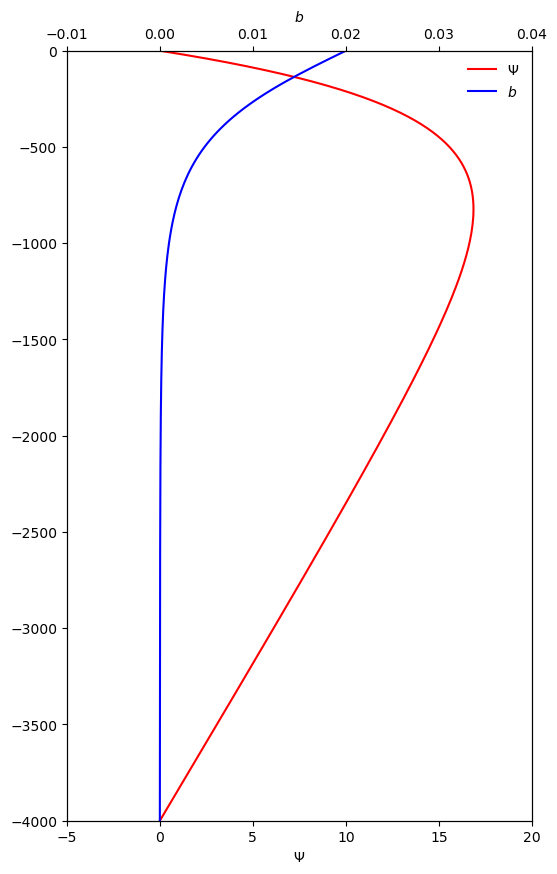

In [5]:
'''
This script shows an example of how to use the equilibrium column model
It solves for the diffusive overturning circulation with prescribed
depth as well as prescribed surface and bottom buoyancies. Notice that
all buoyancies are given relative to the buoyancy in the northern deep
water formation region (b_n=0).     
'''

from pymoc.modules import Equi_Column
from matplotlib import pyplot as plt

#Define some key parameters:
A = 1.0e14    # Area of the basin
kappa = 5.0e-5    # vertical diffusivity
f = 1e-4    # Coriolis parameter
b_s = 0.02    # surface buoyancy
b_bot = 0.0    # bottom buoyancy (should be zero if set by northern deep water formation region)
H = 4000.0    # maximum depth of convection

# create column model instance
m = Equi_Column(A=A, b_bot=b_bot, b_s=b_s, f=f, kappa=kappa, H=H, nz=200)
# solve the model:
m.solve()

# plot overturning and buoyancy profile:
fig = plt.figure(figsize=(6, 10))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
ax1.plot(m.psi, m.z, '-r', label='$\Psi$')
ax2.plot(m.b, m.z, '-b', label='$b$')
plt.ylim((-4e3, 0))
ax1.set_xlim((-5, 20))
ax2.set_xlim((-0.01, 0.04))
ax1.set_xlabel('$\Psi$')
ax2.set_xlabel('$b$')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False)
plt.show()


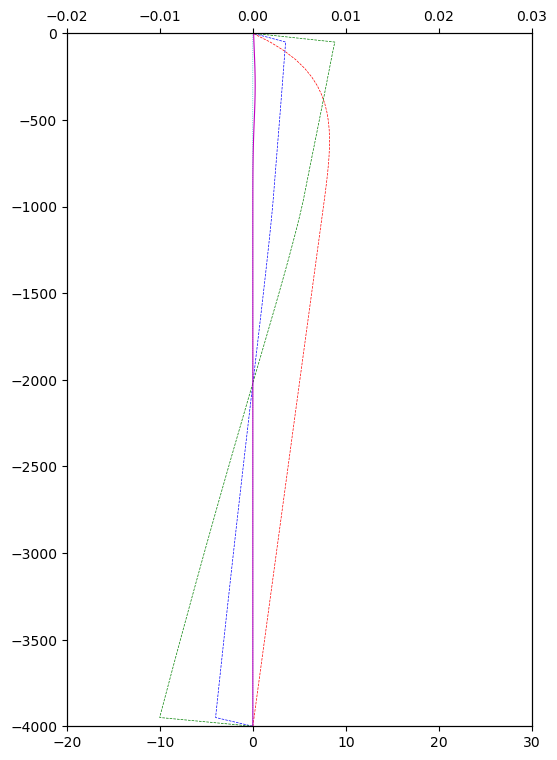

t =  0 years
t =  500 years
t =  1000 years
t =  1500 years
t =  2000 years
t =  2500 years
t =  3000 years
t =  3500 years


In [6]:
#!/usr/bin/env python2
# -*- coding: utf-8 -*-

import sys
sys.path.append('../Modules')
from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

plt.close('all')

# --- PARAMETERS -------------------------------------------------------------

bs = 0.02
bs_north = 0.00036
bAABW = -0.0011
bbot = min(bAABW, bs_north)

y = np.linspace(0, 3e6, 51)
tau = 0.16
offset = 0.0345 * (1 - np.cos(np.pi * (5.55e5 - 1e5) / 8e6))
bs_SO = (0.0345 * (1 - np.cos(np.pi * (y - 1e5) / 8e6)) * (y > 5.55e5)
         + (bAABW - offset) / 5.55e5 * np.maximum(0, 5.55e5 - y)
         + offset * (y < 5.55e5))

dt = 86400. * 30.
MOC_up_iters = int(np.floor(2. * 360 * 86400 / dt))
plot_iters = int(np.ceil(500 * 360 * 86400 / dt))
total_iters = int(np.ceil(4000 * 360 * 86400 / dt))

def kappaeff(z):
    return 1.0 * (1e-4 * (1.1 - np.tanh(np.maximum(z + 2000., 0) / 1000.
            + np.minimum(z + 2000., 0) / 1300.))
            * (1. - np.maximum(-4000. - z + 600., 0.) / 600.)**2)

A_Atl = 7e13
A_north = 5.5e12
A_Pac = 1.7e14

Lx = 1.3e7
Latl = 6. / 21. * Lx
Lpac = 15. / 21. * Lx
K = 1800.
N2min = 2e-7
z = np.linspace(-4000, 0, 80)

def b_Atl(z): return bs * np.exp(z / 300.) + z / z[0] * bbot
def b_Pac(z): return bs * np.exp(z / 300.) + z / z[0] * bbot

# --- MODEL INITIALISATION ---------------------------------------------------

AMOC = Psi_Thermwind(z=z, b1=b_Atl, b2=0.01 * b_Atl(z))
AMOC.solve()
Psi_iso_Atl, Psi_iso_N = AMOC.Psibz()

ZOC = Psi_Thermwind(z=z, b1=b_Atl, b2=b_Pac, f=1e-4)
ZOC.solve()
Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

SO_Atl = Psi_SO(z=z, y=y, b=b_Atl(z), bs=bs_SO, tau=tau, L=Latl, KGM=K)
SO_Atl.solve()
SO_Pac = Psi_SO(z=z, y=y, b=b_Pac(z), bs=bs_SO, tau=tau, L=Lpac, KGM=K)
SO_Pac.solve()

Atl = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs, bbot=bbot, Area=A_Atl, N2min=N2min)
north = Column(z=z, kappa=kappaeff, b=b_Atl, bs=bs_north, bbot=bbot, Area=A_north, N2min=N2min)
Pac = Column(z=z, kappa=kappaeff, b=b_Pac, bs=bs, bbot=bbot, Area=A_Pac, N2min=N2min)

# --- INDONESIAN THROUGHFLOW -------------------------------------------------

def Psi_ITF_profile(z):
    """Depth-dependent ITF profile, following Nadeau & Jansen (2016)."""
    psi0 = 0.25  # peak transport in Sv
    z0 = -300.0  # central depth
    scale = 200.0
    Psi = psi0 * np.exp(-(z - z0)**2 / (2 * scale**2))
    return Psi

Psi_ITF = Psi_ITF_profile(z)

# --- PLOTTING SETUP ---------------------------------------------------------

fig = plt.figure(figsize=(6, 9))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()
plt.ylim((-4e3, 0))
ax1.set_xlim((-20, 30))
ax2.set_xlim((-0.02, 0.030))

# --- TIME INTEGRATION LOOP --------------------------------------------------

for ii in range(total_iters):
    wA_Atl = (Psi_iso_Atl + Psi_zonal_Atl - SO_Atl.Psi - Psi_ITF) * 1e6
    wAN = -Psi_iso_N * 1e6
    wA_Pac = (-Psi_zonal_Pac - SO_Pac.Psi + Psi_ITF) * 1e6

    Atl.timestep(wA=wA_Atl, dt=dt)
    north.timestep(wA=wAN, dt=dt, do_conv=True)
    Pac.timestep(wA=wA_Pac, dt=dt)

    if ii % MOC_up_iters == 0:
        AMOC.update(b1=Atl.b, b2=north.b)
        AMOC.solve()
        Psi_iso_Atl, Psi_iso_N = AMOC.Psibz()

        ZOC.update(b1=Atl.b, b2=Pac.b)
        ZOC.solve()
        Psi_zonal_Atl, Psi_zonal_Pac = ZOC.Psibz()

        SO_Atl.update(b=Atl.b)
        SO_Atl.solve()
        SO_Pac.update(b=Pac.b)
        SO_Pac.solve()

    if ii % plot_iters == 0:
        ax1.plot(AMOC.Psi, AMOC.z, '--r', linewidth=0.5)
        ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=0.5)
        ax1.plot(SO_Atl.Psi - ZOC.Psi, SO_Atl.z, '--b', linewidth=0.5)
        ax1.plot(SO_Pac.Psi + ZOC.Psi, SO_Pac.z, '--g', linewidth=0.5)
        ax1.plot(Psi_ITF, z, '-m', linewidth=0.8)
        plt.pause(0.01)
        print("t = ", round(ii * dt / 86400 / 360), "years")

# Final plot
ax1.plot(Psi_ITF, z, '-m', linewidth=2, label='Ψ_ITF')
ax1.legend(loc=4, frameon=False)
plt.show()


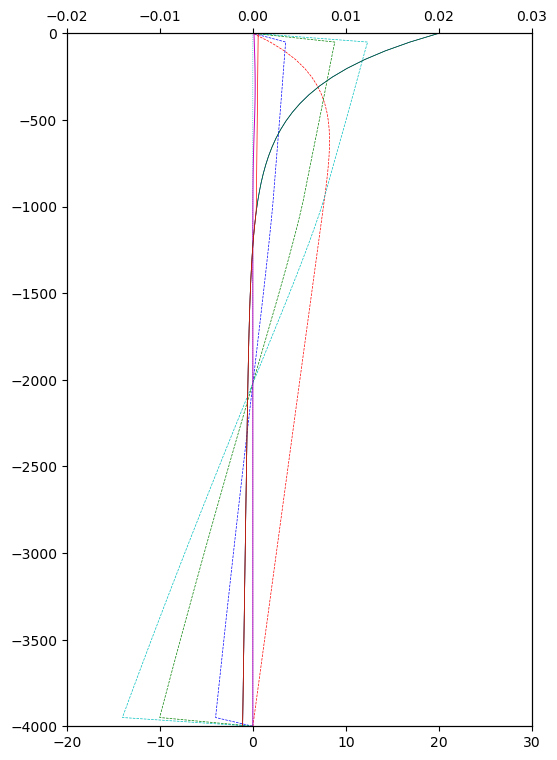

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/1072680795.py:315: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/1072680795.py:381: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


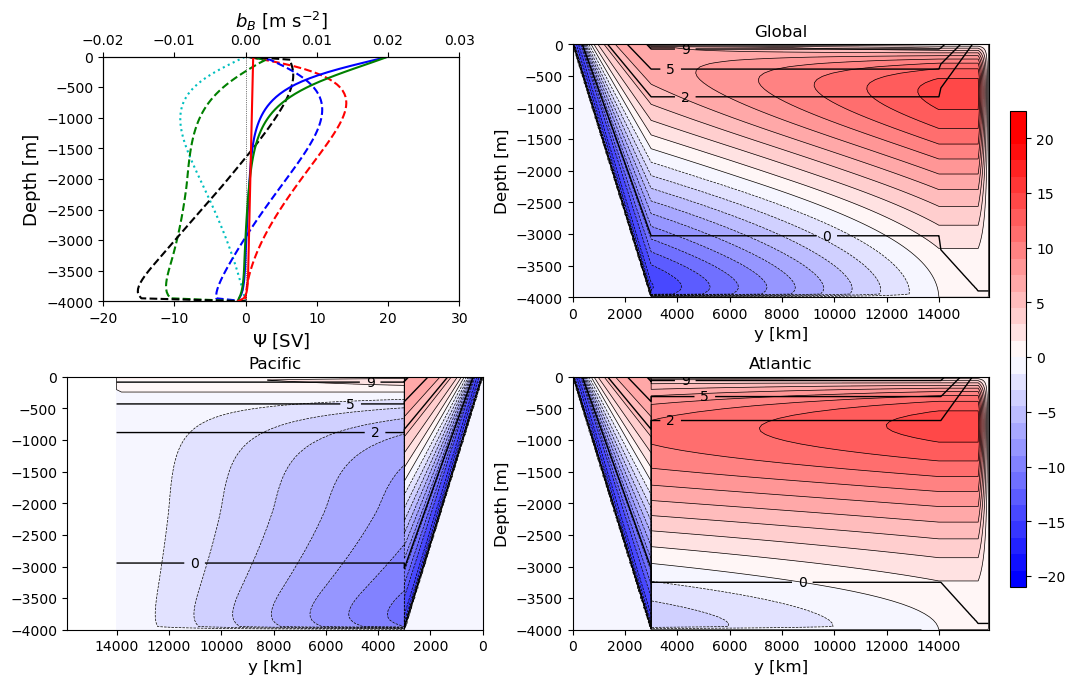

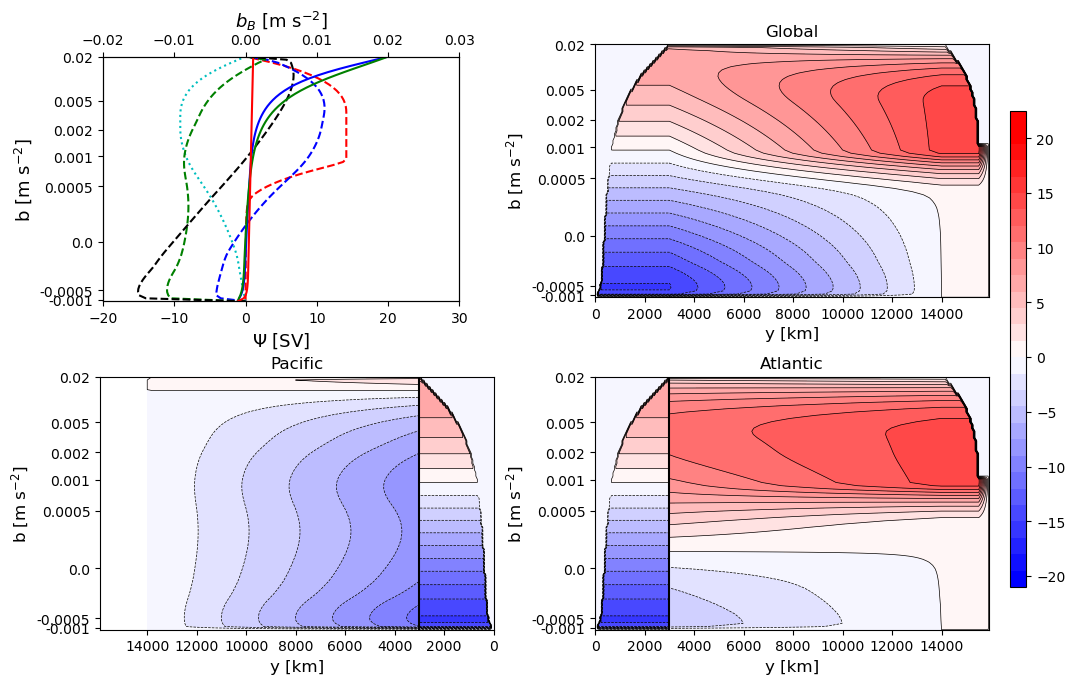

In [10]:
'''
This script shows an example of a three column model for the 
overturning circulation in two basins connected to a channel in the south,
now including a representation of the Indonesian Throughflow (ITF)
as a shallow, inter-basin throughflow following Nadeau & Jansen (2016).
'''

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file=None

# boundary conditions:
bs=0.02
bs_north=0.00036
bAABW=-0.0011
bbot=min(bAABW,bs_north)

# S.O. surface boundary conditions and grid:
y=np.asarray(np.linspace(0,3.e6,51))
tau=0.16
offset=0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6))
bs_SO=(0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
      +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5))

# time-stepping parameters:
dt=86400.*30.
MOC_up_iters=int(np.floor(2.*360*86400/dt))
plot_iters=int(np.ceil(500*360*86400/dt))
total_iters=int(np.ceil(4000*360*86400/dt))

# Effective diffusivity profile:
def kappaeff(z):
    return 1.0*(1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000.
            + np.minimum(z+2000.,0)/1300.))
            *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2)

A_Atl=7e13
A_north=5.5e12
A_Pac=1.7e14

Lx=1.3e7
Latl=6./21.*Lx
Lpac=15./21.*Lx
K=1800.
N2min=2e-7
z=np.asarray(np.linspace(-4000,0,80))

def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

# --- Add Indonesian Throughflow profile (new) ---
def Psi_ITF_profile(z):
    psi0 = 0.25        # 0.25 Sv, typical mean ITF
    z0 = -300.0        # centred around 300 m
    scale = 250.0
    return psi0*np.exp(-(z-z0)**2/(2*scale**2))

Psi_ITF = Psi_ITF_profile(z)

# Create model instances:
AMOC=Psi_Thermwind(z=z,b1=b_Atl,b2=0.01*b_Atl(z))
AMOC.solve()
[Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

ZOC=Psi_Thermwind(z=z,b1=b_Atl,b2=b_Pac,f=1e-4)
ZOC.solve()
[Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

SO_Atl=Psi_SO(z=z,y=y,b=b_Atl(z),bs=bs_SO,tau=tau,L=Latl,KGM=K)
SO_Atl.solve()
SO_Pac=Psi_SO(z=z,y=y,b=b_Pac(z),bs=bs_SO,tau=tau,L=Lpac,KGM=K)
SO_Pac.solve()

Atl=Column(z=z,kappa=kappaeff,b=b_Atl,bs=bs,bbot=bbot,Area=A_Atl,N2min=N2min)
north=Column(z=z,kappa=kappaeff,b=b_Atl,bs=bs_north,bbot=bbot,Area=A_north,N2min=N2min)
Pac=Column(z=z,kappa=kappaeff,b=b_Pac,bs=bs,bbot=bbot,Area=A_Pac,N2min=N2min)

# --- Plot setup ---
fig=plt.figure(figsize=(6,9))
ax1=fig.add_subplot(111)
ax2=ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))

# --- Time-stepping loop ---
for ii in range(total_iters):
    # Include ITF between basins (new terms)
    wA_Atl=(Psi_iso_Atl+Psi_zonal_Atl-SO_Atl.Psi + Psi_ITF)*1e6
    wAN=-Psi_iso_N*1e6
    wA_Pac=(-Psi_zonal_Pac-SO_Pac.Psi - Psi_ITF)*1e6

    Atl.timestep(wA=wA_Atl,dt=dt)
    north.timestep(wA=wAN,dt=dt,do_conv=True)
    Pac.timestep(wA=wA_Pac,dt=dt)

    if ii%MOC_up_iters==0:
        AMOC.update(b1=Atl.b,b2=north.b)
        AMOC.solve()
        [Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

        ZOC.update(b1=Atl.b,b2=Pac.b)
        ZOC.solve()
        [Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

        SO_Atl.update(b=Atl.b)
        SO_Atl.solve()
        SO_Pac.update(b=Pac.b)
        SO_Pac.solve()

    if ii%plot_iters==0:
        ax1.plot(AMOC.Psi,AMOC.z,'--r',linewidth=0.5)
        ax1.plot(ZOC.Psi,ZOC.z,':c',linewidth=0.5)
        ax1.plot(SO_Atl.Psi-ZOC.Psi,SO_Atl.z,'--b',linewidth=0.5)
        ax1.plot(SO_Pac.Psi+ZOC.Psi,SO_Pac.z,'--g',linewidth=0.5)
        ax1.plot(SO_Atl.Psi+SO_Pac.Psi,z,'--c',linewidth=0.5)
        ax2.plot(Atl.b,Atl.z,'-b',linewidth=0.5)
        ax2.plot(Pac.b,Pac.z,'-g',linewidth=0.5)
        ax2.plot(north.b,north.z,'-r',linewidth=0.5)
        # plot ITF magnitude profile for reference
        ax1.plot(Psi_ITF,z,'-m',linewidth=0.7)
        plt.pause(0.01)
        print("t=",round(ii*dt/86400/360),"years")

ax1.plot(AMOC.Psi,AMOC.z,'--r',linewidth=1.5)
ax1.plot(ZOC.Psi,ZOC.z,':c',linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi,SO_Atl.z,'--b',linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi,SO_Pac.z,'--g',linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi,z,'--c',linewidth=1.5)
ax2.plot(Atl.b,Atl.z,'-b',linewidth=1.5)
ax2.plot(Pac.b,Pac.z,'-g',linewidth=1.5)
ax2.plot(north.b,north.z,'-r',linewidth=1.5)
ax1.plot(Psi_ITF,z,'-m',linewidth=1.2,label='Ψ_ITF')
ax1.legend(loc=4,frameon=False)

# --- Diagnostics output if requested ---
if diag_file is not None:
    np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b,
             Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
             Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
             Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid,
             Psi_ITF=Psi_ITF)

#*****************************************************************************
# Below is all just for fancy plots
#*****************************************************************************

blevs=np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
#plevs=np.arange(-21.,23.,2.0)
plevs=np.arange(-21.,23.,1.5)

nb=500;

b_basin=(A_Atl*Atl.b+A_Pac*Pac.b)/(A_Atl+A_Pac);
b_north=north.b;

# Compute total SO residual overturning by first interpolating circulation 
# in both sectors to mean buoyancy profile values and then summing (at constant b).
PsiSO=(np.interp(b_basin,Atl.b,SO_Atl.Psi)
      +np.interp(b_basin,Pac.b,SO_Pac.Psi));
AMOC_bbasin=np.interp(b_basin,AMOC.bgrid,AMOC.Psib(nb=nb));
# this is to Plot adiabatic overturning only:
PsiSO_bgrid=(np.interp(AMOC.bgrid,Atl.b,SO_Atl.Psi)
            +np.interp(AMOC.bgrid,Pac.b,SO_Pac.Psi));

l=y[-1];

bs=1.*bs_SO;bn=1.*b_basin;
bs[-1]=1.*bn[-1]; # if bs is tiny bit warmer there is a zero slope point at the surface which makes the interpolation fail...

# first interpolate buoyancy in channel along constant-slope isopycnals: 
bint=Interpolate_channel(y=y,z=z,bs=bs,bn=bn)
bsouth=bint.gridit()
# buoyancy in the basin is all the same:
lbasin=11000.
ltrans=1500.
lnorth=400.
lchannel=l/1e3
ybasin=np.linspace(0,lbasin,60)+lchannel;
bbasin=np.tile(b_basin,(len(ybasin),1))
bAtl=np.tile(Atl.b,(len(ybasin),1))
bPac=np.tile(Pac.b,(len(ybasin),1))
# interpolate buoyancy in northern ransition region:
ytrans=np.linspace(ltrans/20.,ltrans,20)+lchannel+lbasin;
bn=b_north.copy();
bn[0]=b_basin[0];# Notice that the interpolation procedure assumes that the bottom
#buoyancies in both colums match - which may not be exactly the case depending
# on when in teh time-step data is saved 
bint=Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000.,z=z,bs=Atl.b,bn=bn)
btrans=bint.gridit()
# finally set buyancy in northern deep water formation region:
ynorth=np.linspace(lnorth/20.,lnorth,20)+lchannel+lbasin+ltrans;
bnorth=np.tile(bn,(len(ynorth),1))
# now stick it all together:
ynew=np.concatenate((y/1e3,ybasin,ytrans,ynorth))
bnew=np.concatenate((bsouth,bbasin,btrans,bnorth))
bnew_Atl=np.concatenate((bsouth,bAtl,btrans,bnorth))
bnew_Pac=np.concatenate((bsouth,bPac,np.nan*btrans,np.nan*bnorth))

# Compute z-coordinate and residual overturning streamfunction at all latitudes:
psiarray_b=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_b_Atl=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_b_Pac=np.zeros((len(ynew),len(z))) # overturning in b-coordinates
psiarray_Atl=np.zeros((len(ynew),len(z))) # "residual" overturning in ATl.
psiarray_Pac=np.zeros((len(ynew),len(z))) # "residual" overturning in Pac.
psiarray_z=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning
psiarray_z_Atl=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning
psiarray_z_Pac=np.zeros((len(ynew),len(z)))  # z-space, "eulerian" overturning
for iy in range(1,len(y)):
    # in the channel, interpolate PsiSO onto local isopycnal depth:
    psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
    psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
    psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
    psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO);    
    psiarray_b_Atl[iy,:]=psiarray_b[iy,:];    
    psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)   
    psiarray_b_Pac[iy,:]=psiarray_b[iy,:];    
for iy in range(len(y),len(y)+len(ybasin)):
    # in the basin, linearly interpolate between Psi_SO and Psi_AMOC:
    psiarray_z[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi+SO_Pac.Psi))/lbasin  
    psiarray_z_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psi))/lbasin  
    psiarray_z_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psi))/lbasin  
    psiarray_b[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin
                      +(lchannel+lbasin-ynew[iy])*PsiSO)/lbasin  
    psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin   
    psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin+
                    (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi)
                      -np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin   
    psiarray_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[1]))/lbasin   
    psiarray_b_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi)
                        +np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin   
for iy in range(len(y)+len(ybasin),len(y)+len(ybasin)+len(ytrans)):
    # in the northern transition region keep psi_z constant 
    # and psi_b constant on non-outcropped isopycnals (but zero on outcropped
    # isopycnals):
    psiarray_z[iy,:]=AMOC.Psi      
    psiarray_z_Atl[iy,:]=AMOC.Psi      
    psiarray_z_Pac[iy,:]=np.nan      
    psiarray_b[iy,b_basin<bnew[iy,-1]]=AMOC_bbasin[b_basin<bnew[iy,-1]]      
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],AMOC.bgrid,AMOC.Psib(nb=nb))
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan
for iy in range(len(y)+len(ybasin)+len(ytrans),len(ynew)):
    # in the northern sinking region, all psi decrease linearly to zero:
    psiarray_z[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth      
    psiarray_z_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth      
    psiarray_z_Pac[iy,:]=np.nan     
    psiarray_b[iy,b_basin<bnew[iy,-1]]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])
        *AMOC_bbasin[b_basin<bnew[iy,-1]])/lnorth      
    psiarray_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psibz(nb=nb)[1])/lnorth
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan

# plot z-coordinate overturning and buoyancy structure:
    
fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('Depth [m]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)     
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')

ax1 = fig.add_subplot(222)
CS=ax1.contour(ynew,z,bnew.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Global',fontsize=12)
       
ax1 = fig.add_subplot(223)
CS=ax1.contour(ynew,z,bnew_Pac.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
CS=ax1.contour(ynew,z,bnew_Atl.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()   
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')

# Plot Isopycnal overturning

fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
ax1.plot(np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, ':c', linewidth=1.5)
ax1.plot(np.interp(b_basin,Atl.b,SO_Atl.Psi)
        -np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--b', linewidth=1.5)
ax1.plot(np.interp(b_basin,Pac.b,SO_Pac.Psi)
          +np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--g', linewidth=1.5)
ax1.plot(PsiSO, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)     
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

ax1 = fig.add_subplot(222)
ax1.contour(ynew,z,psiarray_b.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Global',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
       
ax1 = fig.add_subplot(223)
ax1.contour(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
ax1.contour(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()   
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')


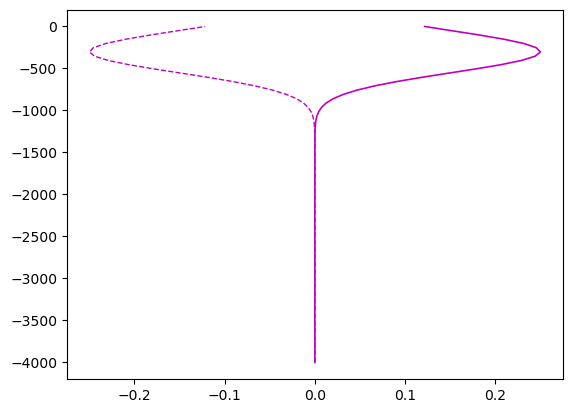

In [13]:
plt.plot(Psi_ITF, z, '-m', linewidth=1.2, label='ITF inflow to Atl')
plt.plot(-Psi_ITF, z, '--m', linewidth=1.0, label='ITF outflow from Pac')
plt.show()

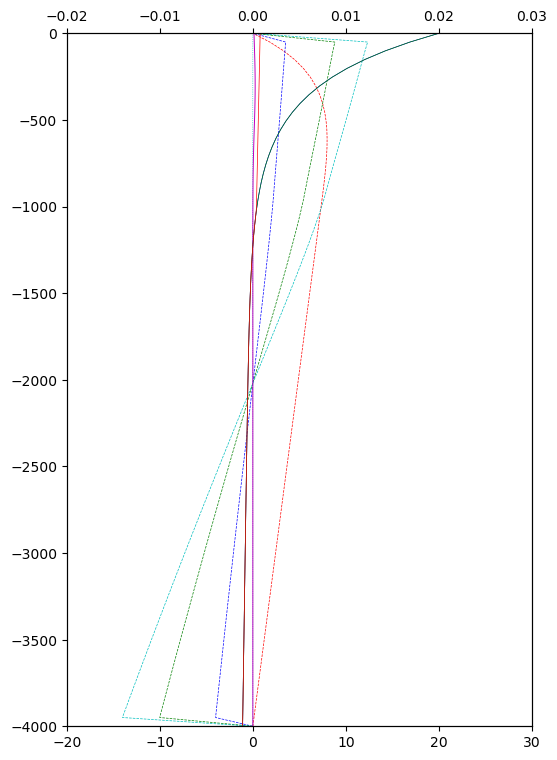

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/3444694680.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/3444694680.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


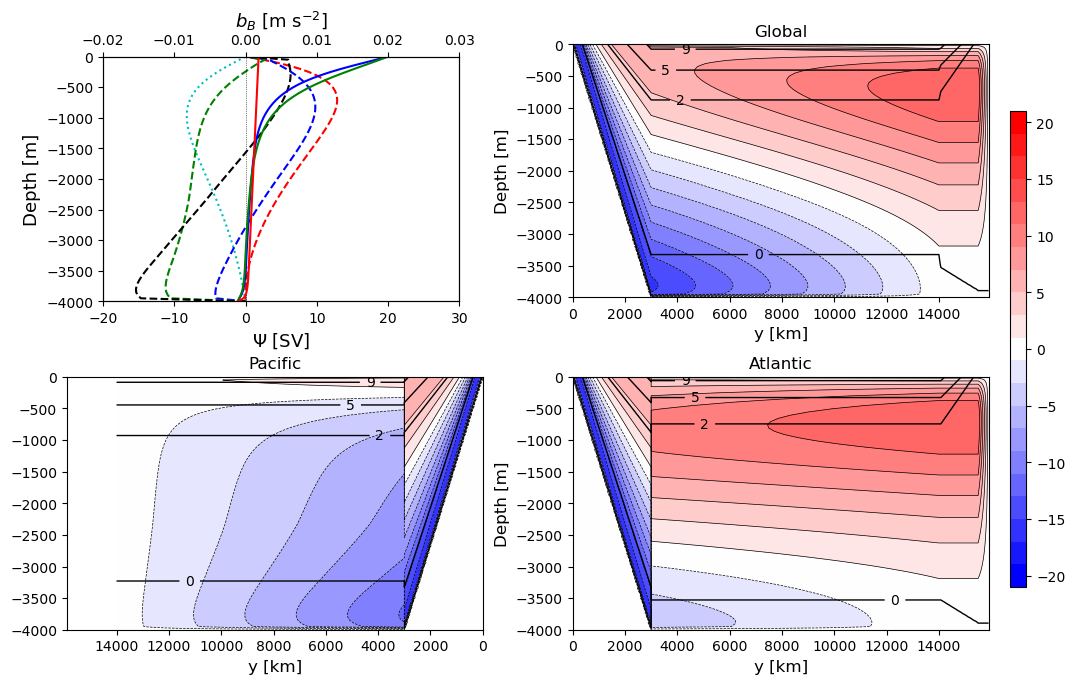

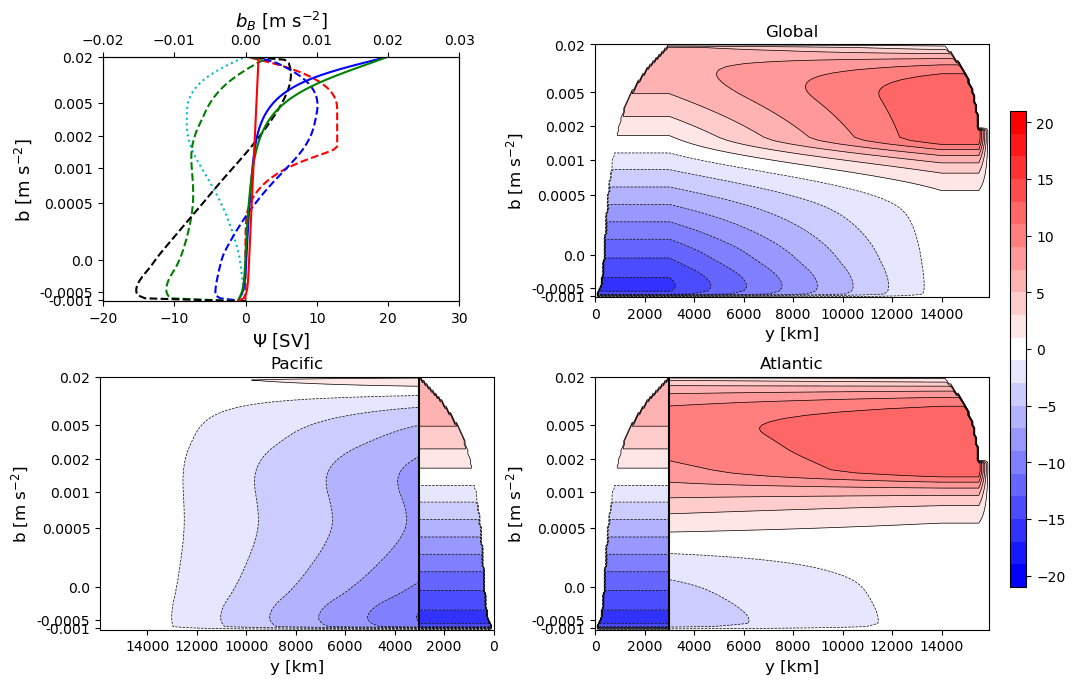

In [28]:
#!/usr/bin/env python2
# -*- coding: utf-8 -*-

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file=None

bs=0.02
bs_north=0.00036
bAABW=-0.0011
bbot=min(bAABW,bs_north)

y=np.asarray(np.linspace(0,3.e6,51))
tau=0.16
offset=0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6))
bs_SO=(0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
      +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5))

dt=86400.*30.
MOC_up_iters=int(np.floor(2.*360*86400/dt))
plot_iters=int(np.ceil(500*360*86400/dt))
total_iters=int(np.ceil(4000*360*86400/dt))

def kappaeff(z):
    return 1.0*(1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000.
            + np.minimum(z+2000.,0)/1300.))
            *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2)

A_Atl=7e13
A_north=5.5e12
A_Pac=1.7e14

Lx=1.3e7
Latl=6./21.*Lx
Lpac=15./21.*Lx
K=1800.
N2min=2e-7

z=np.asarray(np.linspace(-4000,0,80))

def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

def Psi_ITF_profile(z):
    psi0 = 0.25
    z0 = -300.0
    scale = 250.0
    return psi0*np.exp(-(z-z0)**2/(2*scale**2))

Psi_ITF = Psi_ITF_profile(z)

AMOC=Psi_Thermwind(z=z,b1=b_Atl,b2=0.01*b_Atl(z))
AMOC.solve()
[Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

ZOC=Psi_Thermwind(z=z,b1=b_Atl,b2=b_Pac,f=1e-4)
ZOC.solve()
[Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

SO_Atl=Psi_SO(z=z,y=y,b=b_Atl(z),bs=bs_SO,tau=tau,L=Latl,KGM=K)
SO_Atl.solve()
SO_Pac=Psi_SO(z=z,y=y,b=b_Pac(z),bs=bs_SO,tau=tau,L=Lpac,KGM=K)
SO_Pac.solve()

g=9.81
alpha=2e-4
beta=8e-4

fT_init = 0.8
b_init_Atl = b_Atl(z)
bT_init_Atl = fT_init * b_init_Atl
bS_init_Atl = b_init_Atl - bT_init_Atl

b_init_Pac = b_Pac(z)
bT_init_Pac = fT_init * b_init_Pac
bS_init_Pac = b_init_Pac - bT_init_Pac

b_init_north = b_Atl(z)
bT_init_north = fT_init * b_init_north
bS_init_north = b_init_north - bT_init_north

bs_T = fT_init * bs
bs_S = bs - bs_T
bs_north_T = fT_init * bs_north
bs_north_S = bs_north - bs_north_T

Atl_T = Column(z=z,kappa=kappaeff,b=np.copy(bT_init_Atl),bs=bs_T,bbot=np.copy(bbot)*fT_init,Area=A_Atl,N2min=N2min)
Atl_S = Column(z=z,kappa=kappaeff,b=np.copy(bS_init_Atl),bs=bs_S,bbot=np.copy(bbot)*(1.-fT_init),Area=A_Atl,N2min=N2min)
Pac_T = Column(z=z,kappa=kappaeff,b=np.copy(bT_init_Pac),bs=bs_T,bbot=np.copy(bbot)*fT_init,Area=A_Pac,N2min=N2min)
Pac_S = Column(z=z,kappa=kappaeff,b=np.copy(bS_init_Pac),bs=bs_S,bbot=np.copy(bbot)*(1.-fT_init),Area=A_Pac,N2min=N2min)
north_T = Column(z=z,kappa=kappaeff,b=np.copy(bT_init_north),bs=bs_north_T,bbot=np.copy(bbot)*fT_init,Area=A_north,N2min=N2min)
north_S = Column(z=z,kappa=kappaeff,b=np.copy(bS_init_north),bs=bs_north_S,bbot=np.copy(bbot)*(1.-fT_init),Area=A_north,N2min=N2min)

Atl = Column(z=z,kappa=kappaeff,b=lambda Z: (Atl_T.b + Atl_S.b),bs=bs,bbot=bbot,Area=A_Atl,N2min=N2min)
north = Column(z=z,kappa=kappaeff,b=lambda Z: (north_T.b + north_S.b),bs=bs_north,bbot=bbot,Area=A_north,N2min=N2min)
Pac = Column(z=z,kappa=kappaeff,b=lambda Z: (Pac_T.b + Pac_S.b),bs=bs,bbot=bbot,Area=A_Pac,N2min=N2min)

fig=plt.figure(figsize=(6,9))
ax1=fig.add_subplot(111)
ax2=ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))

for ii in range(total_iters):
    Psi_iso_Atl_curr = Psi_iso_Atl
    Psi_zonal_Atl_curr = Psi_zonal_Atl
    SO_Atl_Psi = SO_Atl.Psi
    SO_Pac_Psi = SO_Pac.Psi

    wA_Atl=(Psi_iso_Atl_curr+Psi_zonal_Atl_curr-SO_Atl_Psi + Psi_ITF)*1e6
    wAN=-Psi_iso_N*1e6
    wA_Pac=(-Psi_zonal_Pac-SO_Pac_Psi - Psi_ITF)*1e6

    Atl_T.timestep(wA=wA_Atl,dt=dt)
    Atl_S.timestep(wA=wA_Atl,dt=dt)
    north_T.timestep(wA=wAN,dt=dt,do_conv=True)
    north_S.timestep(wA=wAN,dt=dt,do_conv=True)
    Pac_T.timestep(wA=wA_Pac,dt=dt)
    Pac_S.timestep(wA=wA_Pac,dt=dt)

    Atl.b = Atl_T.b + Atl_S.b
    north.b = north_T.b + north_S.b
    Pac.b = Pac_T.b + Pac_S.b

    if ii%MOC_up_iters==0:
        AMOC.update(b1=Atl.b,b2=north.b)
        AMOC.solve()
        [Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

        ZOC.update(b1=Atl.b,b2=Pac.b)
        ZOC.solve()
        [Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

        SO_Atl.update(b=Atl.b)
        SO_Atl.solve()
        SO_Pac.update(b=Pac.b)
        SO_Pac.solve()

    if ii%plot_iters==0:
        ax1.plot(AMOC.Psi,AMOC.z,'--r',linewidth=0.5)
        ax1.plot(ZOC.Psi,ZOC.z,':c',linewidth=0.5)
        ax1.plot(SO_Atl.Psi-ZOC.Psi,SO_Atl.z,'--b',linewidth=0.5)
        ax1.plot(SO_Pac.Psi+ZOC.Psi,SO_Pac.z,'--g',linewidth=0.5)
        ax1.plot(SO_Atl.Psi+SO_Pac.Psi,z,'--c',linewidth=0.5)
        ax2.plot(Atl.b,Atl.z,'-b',linewidth=0.5)
        ax2.plot(Pac.b,Pac.z,'-g',linewidth=0.5)
        ax2.plot(north.b,north.z,'-r',linewidth=0.5)
        ax1.plot(Psi_ITF,z,'-m',linewidth=0.7)
        plt.pause(0.01)
        print("t=",round(ii*dt/86400/360),"years")

ax1.plot(AMOC.Psi,AMOC.z,'--r',linewidth=1.5)
ax1.plot(ZOC.Psi,ZOC.z,':c',linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi,SO_Atl.z,'--b',linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi,SO_Pac.z,'--g',linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi,z,'--c',linewidth=1.5)
ax2.plot(Atl.b,Atl.z,'-b',linewidth=1.5)
ax2.plot(Pac.b,Pac.z,'-g',linewidth=1.5)
ax2.plot(north.b,north.z,'-r',linewidth=1.5)
ax1.plot(Psi_ITF,z,'-m',linewidth=1.2,label='Ψ_ITF')
ax1.legend(loc=4,frameon=False)

if diag_file is not None:
    np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b,
             Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
             Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
             Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid,
             Psi_ITF=Psi_ITF, bT_Atl=Atl_T.b, bS_Atl=Atl_S.b)

blevs=np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
plevs=np.arange(-21.,23.,2)
nb=500

b_basin=(A_Atl*Atl.b+A_Pac*Pac.b)/(A_Atl+A_Pac)
b_north=north.b

PsiSO=(np.interp(b_basin,Atl.b,SO_Atl.Psi) + np.interp(b_basin,Pac.b,SO_Pac.Psi))
AMOC_bbasin=np.interp(b_basin,AMOC.bgrid,AMOC.Psib(nb=nb))
PsiSO_bgrid=(np.interp(AMOC.bgrid,Atl.b,SO_Atl.Psi) + np.interp(AMOC.bgrid,Pac.b,SO_Pac.Psi))

l=y[-1]

bs=1.*bs_SO; bn=1.*b_basin
bs[-1]=1.*bn[-1]

bint=Interpolate_channel(y=y,z=z,bs=bs,bn=bn)
bsouth=bint.gridit()
lbasin=11000.
ltrans=1500.
lnorth=400.
lchannel=l/1e3
ybasin=np.linspace(0,lbasin,60)+lchannel
bbasin=np.tile(b_basin,(len(ybasin),1))
bAtl=np.tile(Atl.b,(len(ybasin),1))
bPac=np.tile(Pac.b,(len(ybasin),1))
ytrans=np.linspace(ltrans/20.,ltrans,20)+lchannel+lbasin
bn=b_north.copy()
bn[0]=b_basin[0]
bint=Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000.,z=z,bs=Atl.b,bn=bn)
btrans=bint.gridit()
ynorth=np.linspace(lnorth/20.,lnorth,20)+lchannel+lbasin+ltrans
bnorth=np.tile(bn,(len(ynorth),1))

ynew=np.concatenate((y/1e3,ybasin,ytrans,ynorth))
bnew=np.concatenate((bsouth,bbasin,btrans,bnorth))
bnew_Atl=np.concatenate((bsouth,bAtl,btrans,bnorth))
bnew_Pac=np.concatenate((bsouth,bPac,np.nan*btrans,np.nan*bnorth))

psiarray_b=np.zeros((len(ynew),len(z)))
psiarray_b_Atl=np.zeros((len(ynew),len(z)))
psiarray_b_Pac=np.zeros((len(ynew),len(z)))
psiarray_Atl=np.zeros((len(ynew),len(z)))
psiarray_Pac=np.zeros((len(ynew),len(z)))
psiarray_z=np.zeros((len(ynew),len(z)))
psiarray_z_Atl=np.zeros((len(ynew),len(z)))
psiarray_z_Pac=np.zeros((len(ynew),len(z)))

for iy in range(1,len(y)):
    psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
    psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
    psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
    psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)
    psiarray_b_Atl[iy,:]=psiarray_b[iy,:]
    psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)
    psiarray_b_Pac[iy,:]=psiarray_b[iy,:]

for iy in range(len(y),len(y)+len(ybasin)):
    psiarray_z[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi+SO_Pac.Psi))/lbasin
    psiarray_z_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psi))/lbasin
    psiarray_z_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psi))/lbasin
    psiarray_b[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin + (lchannel+lbasin-ynew[iy])*PsiSO)/lbasin
    psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin
    psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin + (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi) - np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin
    psiarray_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[1]))/lbasin
    psiarray_b_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi) + np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin

for iy in range(len(y)+len(ybasin),len(y)+len(ybasin)+len(ytrans)):
    psiarray_z[iy,:]=AMOC.Psi
    psiarray_z_Atl[iy,:]=AMOC.Psi
    psiarray_z_Pac[iy,:]=np.nan
    psiarray_b[iy,b_basin<bnew[iy,-1]]=AMOC_bbasin[b_basin<bnew[iy,-1]]
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],AMOC.bgrid,AMOC.Psib(nb=nb))
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan

for iy in range(len(y)+len(ybasin)+len(ytrans),len(ynew)):
    psiarray_z[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth
    psiarray_z_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth
    psiarray_z_Pac[iy,:]=np.nan
    psiarray_b[iy,b_basin<bnew[iy,-1]]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC_bbasin[b_basin<bnew[iy,-1]])/lnorth
    psiarray_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psibz(nb=nb)[1])/lnorth
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan
#

fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('Depth [m]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')

ax1 = fig.add_subplot(222)
CS=ax1.contour(ynew,z,bnew.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Global',fontsize=12)

ax1 = fig.add_subplot(223)
CS=ax1.contour(ynew,z,bnew_Pac.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
CS=ax1.contour(ynew,z,bnew_Atl.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')

fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)

AMOC_T = Psi_Thermwind(z=z,b1=Atl_T.b,b2=0.01*Atl_T.b)
AMOC_T.solve()
AMOC_S = Psi_Thermwind(z=z,b1=Atl_S.b,b2=0.01*Atl_S.b)
AMOC_S.solve()

ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
ax1.plot(np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, ':c', linewidth=1.5)
ax1.plot(np.interp(b_basin,Atl.b,SO_Atl.Psi) - np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--b', linewidth=1.5)
ax1.plot(np.interp(b_basin,Pac.b,SO_Pac.Psi) + np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--g', linewidth=1.5)
ax1.plot(PsiSO, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

ax1 = fig.add_subplot(222)
ax1.contour(ynew,z,psiarray_b.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Global',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

ax1 = fig.add_subplot(223)
ax1.contour(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
ax1.contour(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')

plt.show()


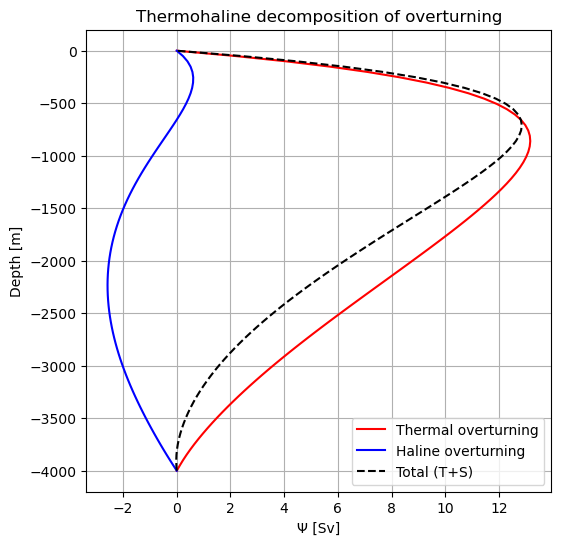

In [15]:
AMOC_T = Psi_Thermwind(z=z, b1=Atl_T.b, b2=north_T.b)
AMOC_T.solve()
AMOC_S = Psi_Thermwind(z=z, b1=Atl_S.b, b2=north_S.b)
AMOC_S.solve()
[Psi_iso_Atl_T, Psi_iso_N_T] = AMOC_T.Psibz()
[Psi_iso_Atl_S, Psi_iso_N_S] = AMOC_S.Psibz()
plt.figure(figsize=(6,6))
plt.plot(AMOC_T.Psi, AMOC_T.z, '-r', label='Thermal overturning')
plt.plot(AMOC_S.Psi, AMOC_S.z, '-b', label='Haline overturning')
plt.plot(AMOC_T.Psi + AMOC_S.Psi, AMOC_T.z, '--k', label='Total (T+S)')
plt.xlabel('Ψ [Sv]')
plt.ylabel('Depth [m]')
plt.title('Thermohaline decomposition of overturning')
plt.legend()
plt.grid(True)
plt.show()


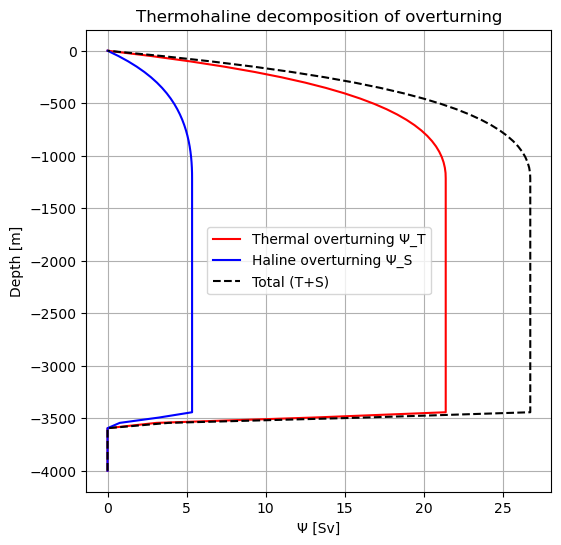

In [20]:
# compute buoyancy-coordinate streamfunctions for T and S
Psi_T, bgrid_T = AMOC_T.Psibz()
Psi_S, bgrid_S = AMOC_S.Psibz()

# interpolate both onto the common basin buoyancy grid
psiarray_b_T = np.interp(b_basin, bgrid_T, Psi_T)
psiarray_b_S = np.interp(b_basin, bgrid_S, Psi_S)

plt.figure(figsize=(6,6))
plt.plot(Psi_T, z, '-r', label='Thermal overturning Ψ_T')
plt.plot(Psi_S, z, '-b', label='Haline overturning Ψ_S')
plt.plot(Psi_T + Psi_S, z, '--k', label='Total (T+S)')
plt.xlabel('Ψ [Sv]')
plt.ylabel('Depth [m]')
plt.title('Thermohaline decomposition of overturning')
plt.legend()
plt.grid(True)
plt.show()


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/682165907.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


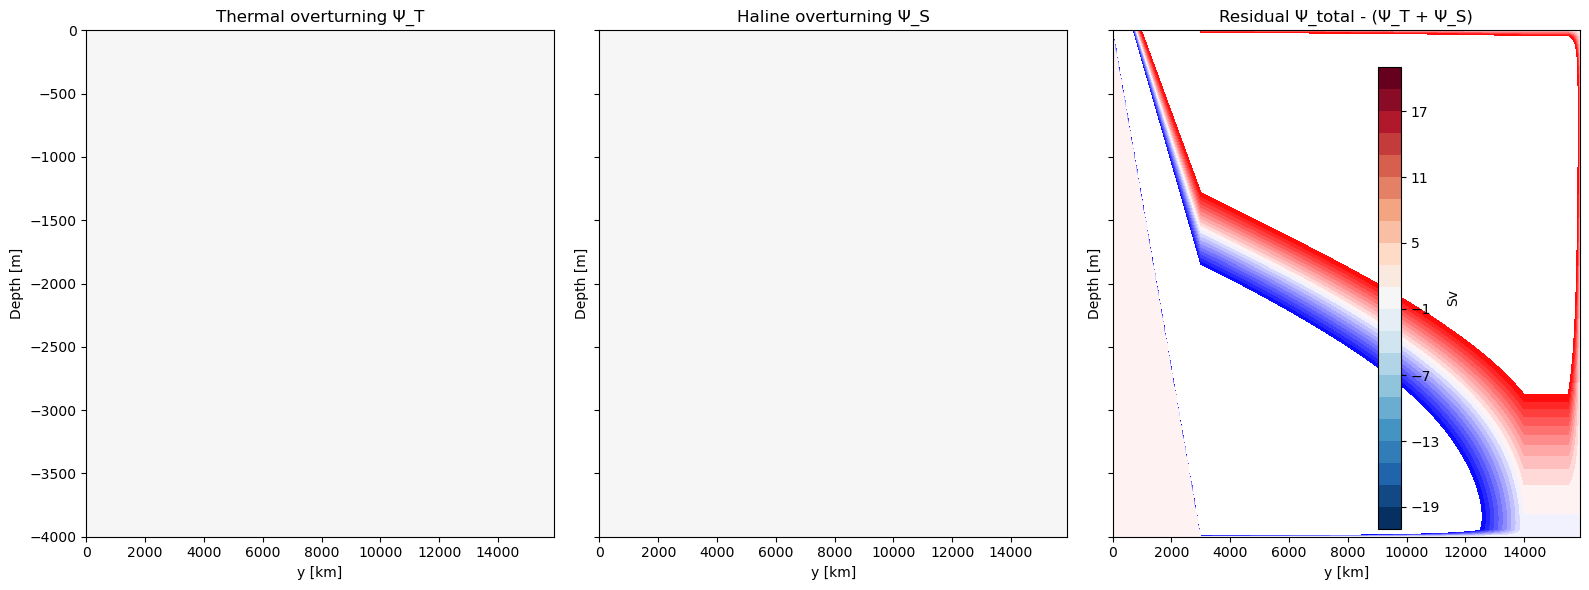

In [23]:
psiarray_z_T = np.zeros((len(ynew), len(z)))
psiarray_z_S = np.zeros((len(ynew), len(z)))

for iy in range(len(ynew)):
    bvals = bnew[iy, :]
    bclip_T = np.clip(bvals, bgrid_T.min(), bgrid_T.max())
    bclip_S = np.clip(bvals, bgrid_S.min(), bgrid_S.max())
    psiarray_z_T[iy, :] = np.interp(bclip_T, bgrid_T, Psi_T)
    psiarray_z_S[iy, :] = np.interp(bclip_S, bgrid_S, Psi_S)

fig, axs = plt.subplots(1, 3, figsize=(16,6), sharey=True)

CS1 = axs[0].contourf(ynew, z, psiarray_z_T.T, levels=plevs,
                      cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
axs[0].set_title('Thermal overturning Ψ_T')

CS2 = axs[1].contourf(ynew, z, psiarray_z_S.T, levels=plevs,
                      cmap=plt.cm.RdBu_r, vmin=-20, vmax=20)
axs[1].set_title('Haline overturning Ψ_S')

residual = psiarray_z - (psiarray_z_T + psiarray_z_S)
CS3 = axs[2].contourf(ynew, z, residual.T, levels=np.linspace(-2,2,21),
                      cmap='bwr')
axs[2].set_title('Residual Ψ_total - (Ψ_T + Ψ_S)')

for ax in axs:
    ax.set_xlabel('y [km]')
    ax.set_ylabel('Depth [m]')

plt.colorbar(CS1, ax=axs, orientation='vertical', fraction=0.046, pad=0.04, label='Sv')
plt.tight_layout()
plt.show()


In [24]:
print("bgrid_T range:", bgrid_T.min(), bgrid_T.max())
print("bnew range:", np.nanmin(bnew), np.nanmax(bnew))
print("Psi_T range:", np.nanmin(Psi_T), np.nanmax(Psi_T))
print("psiarray_z_T contains NaNs?", np.isnan(psiarray_z_T).all())


bgrid_T range: 2.9124823238042743 21.399184895522694
bnew range: -0.0011 0.02
Psi_T range: -2.220446049250313e-15 21.399184895522694
psiarray_z_T contains NaNs? False


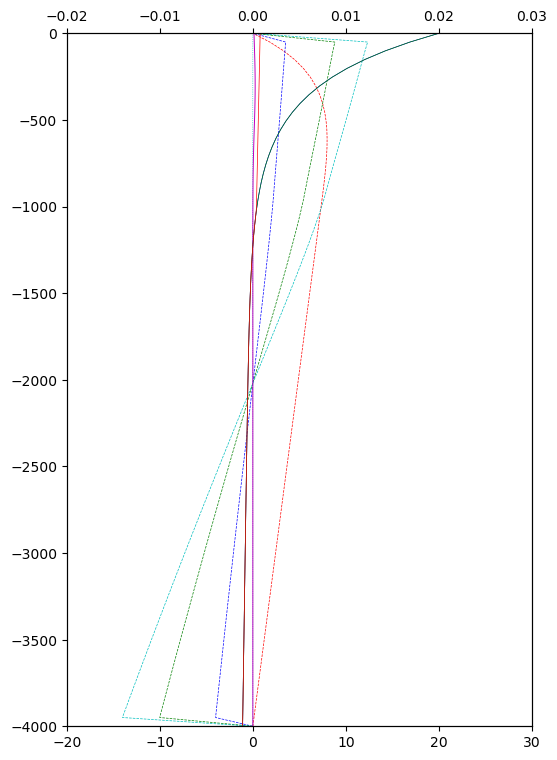

t= 0 years
t= 500 years
t= 1000 years
t= 1500 years
t= 2000 years
t= 2500 years
t= 3000 years
t= 3500 years


/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/2044955890.py:375: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/xw/qtyb7crd12j_rxn05n4n9g_c0000gq/T/ipykernel_74905/2044955890.py:443: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


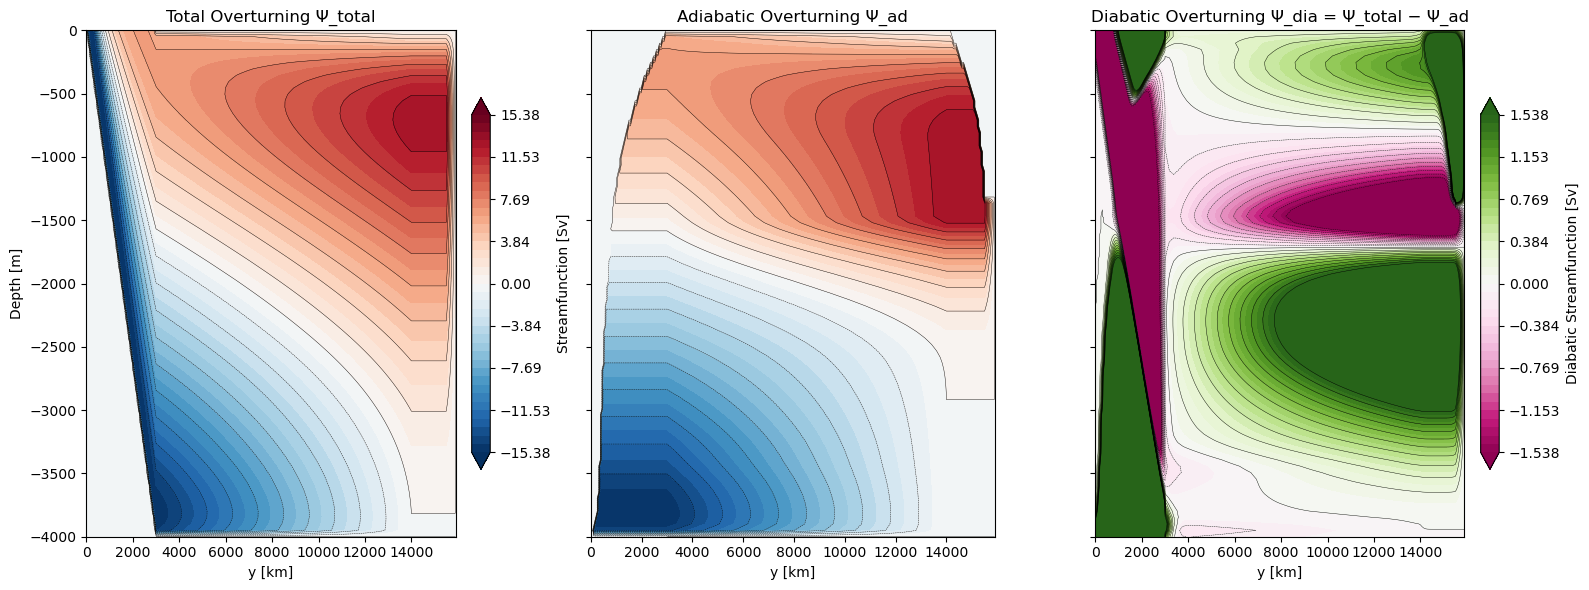

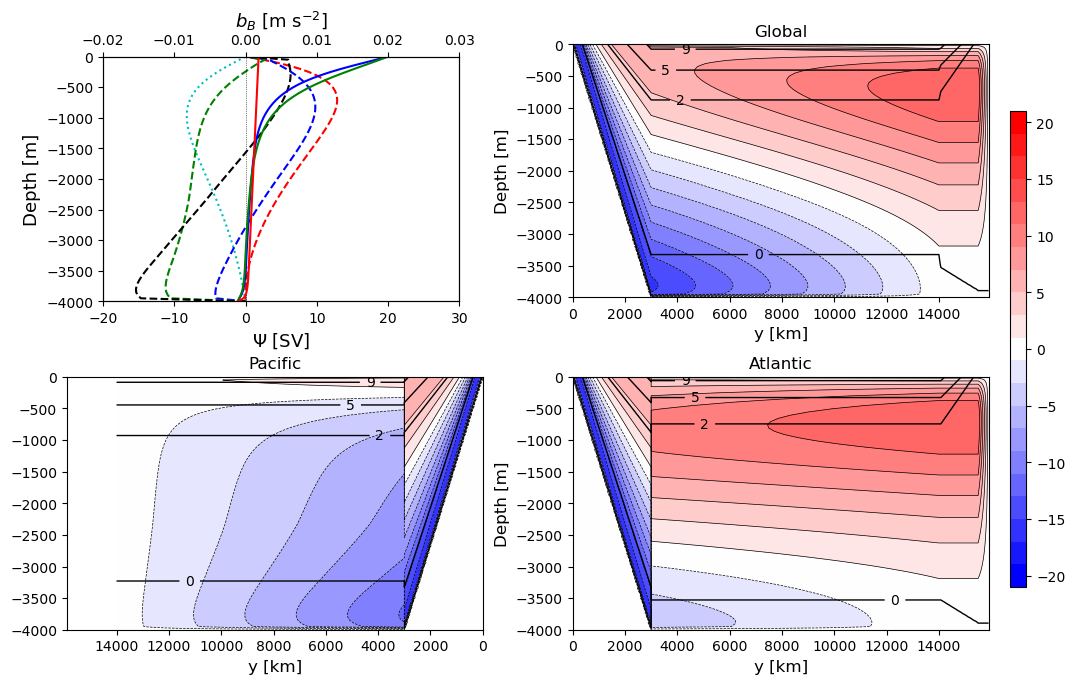

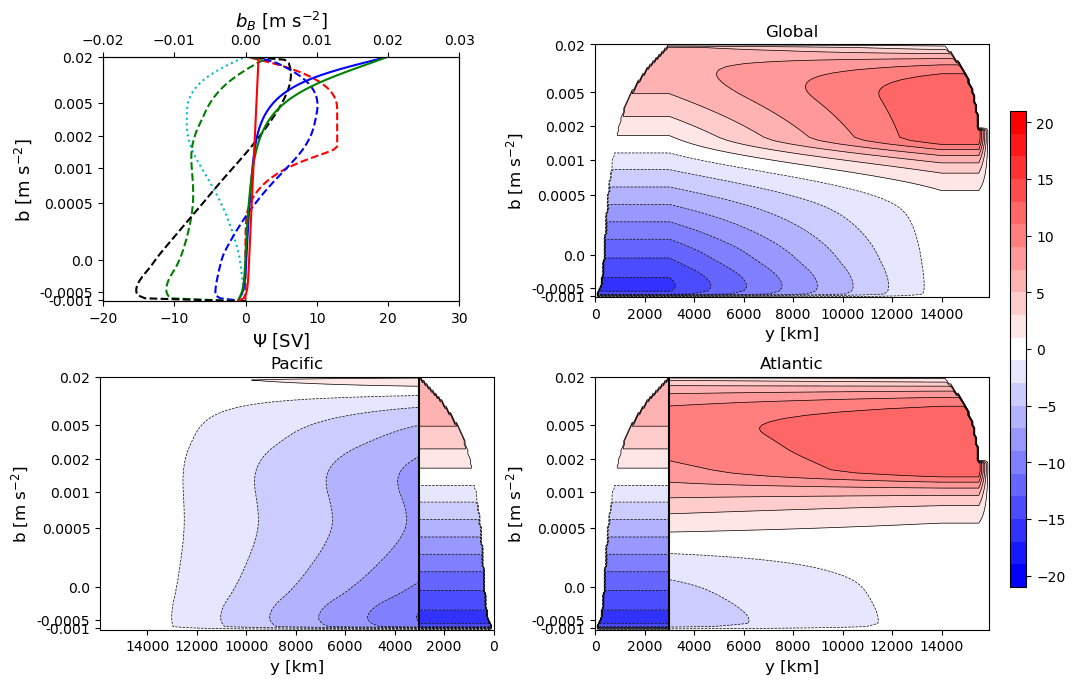

In [34]:
#!/usr/bin/env python2
# -*- coding: utf-8 -*-

from pymoc.modules import Psi_Thermwind, Psi_SO, Column
from pymoc.plotting import Interpolate_channel, Interpolate_twocol
import numpy as np
from matplotlib import pyplot as plt

diag_file=None

bs=0.02
bs_north=0.00036
bAABW=-0.0011
bbot=min(bAABW,bs_north)

y=np.asarray(np.linspace(0,3.e6,51))
tau=0.16
offset=0.0345*(1-np.cos(np.pi*(5.55e5-1.e5)/8e6))
bs_SO=(0.0345*(1-np.cos(np.pi*(y-1.e5)/8e6))*(y>5.55e5)
      +(bAABW-offset)/5.55e5*np.maximum(0,5.55e5-y)+offset*(y<5.55e5))

dt=86400.*30.
MOC_up_iters=int(np.floor(2.*360*86400/dt))
plot_iters=int(np.ceil(500*360*86400/dt))
total_iters=int(np.ceil(4000*360*86400/dt))

def kappaeff(z):
    return 1.0*(1e-4*(1.1-np.tanh(np.maximum(z+2000.,0)/1000.
            + np.minimum(z+2000.,0)/1300.))
            *(1.-np.maximum(-4000.-z+600.,0.)/600.)**2)

A_Atl=7e13
A_north=5.5e12
A_Pac=1.7e14

Lx=1.3e7
Latl=6./21.*Lx
Lpac=15./21.*Lx
K=1800.
N2min=2e-7

z=np.asarray(np.linspace(-4000,0,80))

def b_Atl(z): return bs*np.exp(z/300.)+z/z[0]*bbot
def b_Pac(z): return bs*np.exp(z/300.)+z/z[0]*bbot

def Psi_ITF_profile(z):
    psi0 = 0.25
    z0 = -300.0
    scale = 250.0
    return psi0*np.exp(-(z-z0)**2/(2*scale**2))

Psi_ITF = Psi_ITF_profile(z)

AMOC=Psi_Thermwind(z=z,b1=b_Atl,b2=0.01*b_Atl(z))
AMOC.solve()
[Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

ZOC=Psi_Thermwind(z=z,b1=b_Atl,b2=b_Pac,f=1e-4)
ZOC.solve()
[Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

SO_Atl=Psi_SO(z=z,y=y,b=b_Atl(z),bs=bs_SO,tau=tau,L=Latl,KGM=K)
SO_Atl.solve()
SO_Pac=Psi_SO(z=z,y=y,b=b_Pac(z),bs=bs_SO,tau=tau,L=Lpac,KGM=K)
SO_Pac.solve()

g=9.81
alpha=2e-4
beta=8e-4

fT_init = 0.8
b_init_Atl = b_Atl(z)
bT_init_Atl = fT_init * b_init_Atl
bS_init_Atl = b_init_Atl - bT_init_Atl

b_init_Pac = b_Pac(z)
bT_init_Pac = fT_init * b_init_Pac
bS_init_Pac = b_init_Pac - bT_init_Pac

b_init_north = b_Atl(z)
bT_init_north = fT_init * b_init_north
bS_init_north = b_init_north - bT_init_north

bs_T = fT_init * bs
bs_S = bs - bs_T
bs_north_T = fT_init * bs_north
bs_north_S = bs_north - bs_north_T

Atl_T = Column(z=z,kappa=kappaeff,b=np.copy(bT_init_Atl),bs=bs_T,bbot=np.copy(bbot)*fT_init,Area=A_Atl,N2min=N2min)
Atl_S = Column(z=z,kappa=kappaeff,b=np.copy(bS_init_Atl),bs=bs_S,bbot=np.copy(bbot)*(1.-fT_init),Area=A_Atl,N2min=N2min)
Pac_T = Column(z=z,kappa=kappaeff,b=np.copy(bT_init_Pac),bs=bs_T,bbot=np.copy(bbot)*fT_init,Area=A_Pac,N2min=N2min)
Pac_S = Column(z=z,kappa=kappaeff,b=np.copy(bS_init_Pac),bs=bs_S,bbot=np.copy(bbot)*(1.-fT_init),Area=A_Pac,N2min=N2min)
north_T = Column(z=z,kappa=kappaeff,b=np.copy(bT_init_north),bs=bs_north_T,bbot=np.copy(bbot)*fT_init,Area=A_north,N2min=N2min)
north_S = Column(z=z,kappa=kappaeff,b=np.copy(bS_init_north),bs=bs_north_S,bbot=np.copy(bbot)*(1.-fT_init),Area=A_north,N2min=N2min)

Atl = Column(z=z,kappa=kappaeff,b=lambda Z: (Atl_T.b + Atl_S.b),bs=bs,bbot=bbot,Area=A_Atl,N2min=N2min)
north = Column(z=z,kappa=kappaeff,b=lambda Z: (north_T.b + north_S.b),bs=bs_north,bbot=bbot,Area=A_north,N2min=N2min)
Pac = Column(z=z,kappa=kappaeff,b=lambda Z: (Pac_T.b + Pac_S.b),bs=bs,bbot=bbot,Area=A_Pac,N2min=N2min)

fig=plt.figure(figsize=(6,9))
ax1=fig.add_subplot(111)
ax2=ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))

for ii in range(total_iters):
    Psi_iso_Atl_curr = Psi_iso_Atl
    Psi_zonal_Atl_curr = Psi_zonal_Atl
    SO_Atl_Psi = SO_Atl.Psi
    SO_Pac_Psi = SO_Pac.Psi

    wA_Atl=(Psi_iso_Atl_curr+Psi_zonal_Atl_curr-SO_Atl_Psi + Psi_ITF)*1e6
    wAN=-Psi_iso_N*1e6
    wA_Pac=(-Psi_zonal_Pac-SO_Pac_Psi - Psi_ITF)*1e6

    Atl_T.timestep(wA=wA_Atl,dt=dt)
    Atl_S.timestep(wA=wA_Atl,dt=dt)
    north_T.timestep(wA=wAN,dt=dt,do_conv=True)
    north_S.timestep(wA=wAN,dt=dt,do_conv=True)
    Pac_T.timestep(wA=wA_Pac,dt=dt)
    Pac_S.timestep(wA=wA_Pac,dt=dt)

    Atl.b = Atl_T.b + Atl_S.b
    north.b = north_T.b + north_S.b
    Pac.b = Pac_T.b + Pac_S.b

    if ii%MOC_up_iters==0:
        AMOC.update(b1=Atl.b,b2=north.b)
        AMOC.solve()
        [Psi_iso_Atl,Psi_iso_N]=AMOC.Psibz()

        ZOC.update(b1=Atl.b,b2=Pac.b)
        ZOC.solve()
        [Psi_zonal_Atl,Psi_zonal_Pac]=ZOC.Psibz()

        SO_Atl.update(b=Atl.b)
        SO_Atl.solve()
        SO_Pac.update(b=Pac.b)
        SO_Pac.solve()

    if ii%plot_iters==0:
        ax1.plot(AMOC.Psi,AMOC.z,'--r',linewidth=0.5)
        ax1.plot(ZOC.Psi,ZOC.z,':c',linewidth=0.5)
        ax1.plot(SO_Atl.Psi-ZOC.Psi,SO_Atl.z,'--b',linewidth=0.5)
        ax1.plot(SO_Pac.Psi+ZOC.Psi,SO_Pac.z,'--g',linewidth=0.5)
        ax1.plot(SO_Atl.Psi+SO_Pac.Psi,z,'--c',linewidth=0.5)
        ax2.plot(Atl.b,Atl.z,'-b',linewidth=0.5)
        ax2.plot(Pac.b,Pac.z,'-g',linewidth=0.5)
        ax2.plot(north.b,north.z,'-r',linewidth=0.5)
        ax1.plot(Psi_ITF,z,'-m',linewidth=0.7)
        plt.pause(0.01)
        print("t=",round(ii*dt/86400/360),"years")

ax1.plot(AMOC.Psi,AMOC.z,'--r',linewidth=1.5)
ax1.plot(ZOC.Psi,ZOC.z,':c',linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi,SO_Atl.z,'--b',linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi,SO_Pac.z,'--g',linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi,z,'--c',linewidth=1.5)
ax2.plot(Atl.b,Atl.z,'-b',linewidth=1.5)
ax2.plot(Pac.b,Pac.z,'-g',linewidth=1.5)
ax2.plot(north.b,north.z,'-r',linewidth=1.5)
ax1.plot(Psi_ITF,z,'-m',linewidth=1.2,label='Ψ_ITF')
ax1.legend(loc=4,frameon=False)

if diag_file is not None:
    np.savez(diag_file, b_Atl=Atl.b, b_Pac=Pac.b, b_north=north.b,
             Psi_SO_Atl=SO_Atl.Psi, Psi_SO_Pac=SO_Pac.Psi,
             Psi_ZOC=ZOC.Psi, Psib_ZOC=ZOC.Psib(), bgrid_ZOC=ZOC.bgrid,
             Psi_AMOC=AMOC.Psi, Psib_AMOC=AMOC.Psib(), bgrid_AMOC=AMOC.bgrid,
             Psi_ITF=Psi_ITF, bT_Atl=Atl_T.b, bS_Atl=Atl_S.b)

blevs=np.array([-0.004,-0.002,0.0,0.004,0.01,0.018])
plevs=np.arange(-21.,23.,2)
nb=500

b_basin=(A_Atl*Atl.b+A_Pac*Pac.b)/(A_Atl+A_Pac)
b_north=north.b

PsiSO=(np.interp(b_basin,Atl.b,SO_Atl.Psi) + np.interp(b_basin,Pac.b,SO_Pac.Psi))
AMOC_bbasin=np.interp(b_basin,AMOC.bgrid,AMOC.Psib(nb=nb))
PsiSO_bgrid=(np.interp(AMOC.bgrid,Atl.b,SO_Atl.Psi) + np.interp(AMOC.bgrid,Pac.b,SO_Pac.Psi))

l=y[-1]

bs=1.*bs_SO; bn=1.*b_basin
bs[-1]=1.*bn[-1]

bint=Interpolate_channel(y=y,z=z,bs=bs,bn=bn)
bsouth=bint.gridit()
lbasin=11000.
ltrans=1500.
lnorth=400.
lchannel=l/1e3
ybasin=np.linspace(0,lbasin,60)+lchannel
bbasin=np.tile(b_basin,(len(ybasin),1))
bAtl=np.tile(Atl.b,(len(ybasin),1))
bPac=np.tile(Pac.b,(len(ybasin),1))
ytrans=np.linspace(ltrans/20.,ltrans,20)+lchannel+lbasin
bn=b_north.copy()
bn[0]=b_basin[0]
bint=Interpolate_twocol(y=ytrans*1000.-ytrans[0]*1000.,z=z,bs=Atl.b,bn=bn)
btrans=bint.gridit()
ynorth=np.linspace(lnorth/20.,lnorth,20)+lchannel+lbasin+ltrans
bnorth=np.tile(bn,(len(ynorth),1))

ynew=np.concatenate((y/1e3,ybasin,ytrans,ynorth))
bnew=np.concatenate((bsouth,bbasin,btrans,bnorth))
bnew_Atl=np.concatenate((bsouth,bAtl,btrans,bnorth))
bnew_Pac=np.concatenate((bsouth,bPac,np.nan*btrans,np.nan*bnorth))

psiarray_b=np.zeros((len(ynew),len(z)))
psiarray_b_Atl=np.zeros((len(ynew),len(z)))
psiarray_b_Pac=np.zeros((len(ynew),len(z)))
psiarray_Atl=np.zeros((len(ynew),len(z)))
psiarray_Pac=np.zeros((len(ynew),len(z)))
psiarray_z=np.zeros((len(ynew),len(z)))
psiarray_z_Atl=np.zeros((len(ynew),len(z)))
psiarray_z_Pac=np.zeros((len(ynew),len(z)))

for iy in range(1,len(y)):
    psiarray_z[iy,:]=np.interp(bnew[iy,:],b_basin,SO_Atl.Psi+SO_Pac.Psi)
    psiarray_z_Atl[iy,:]=psiarray_z[iy,:]
    psiarray_z_Pac[iy,:]=psiarray_z[iy,:]
    psiarray_b[iy,b_basin<bs_SO[iy]]=PsiSO[b_basin<bs_SO[iy]]
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)
    psiarray_b_Atl[iy,:]=psiarray_b[iy,:]
    psiarray_Pac[iy,:]=np.interp(bnew[iy,:],b_basin,PsiSO)
    psiarray_b_Pac[iy,:]=psiarray_b[iy,:]

for iy in range(len(y),len(y)+len(ybasin)):
    psiarray_z[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi+SO_Pac.Psi))/lbasin
    psiarray_z_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psi+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psi))/lbasin
    psiarray_z_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psi))/lbasin
    psiarray_b[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin + (lchannel+lbasin-ynew[iy])*PsiSO)/lbasin
    psiarray_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC.Psibz(nb=nb)[0]+(lchannel+lbasin-ynew[iy])*(SO_Atl.Psi-ZOC.Psibz()[0]))/lbasin
    psiarray_b_Atl[iy,:]=((ynew[iy]-lchannel)*AMOC_bbasin + (lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Atl.b,SO_Atl.Psi) - np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin
    psiarray_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(SO_Pac.Psi+ZOC.Psibz()[1]))/lbasin
    psiarray_b_Pac[iy,:]=((lchannel+lbasin-ynew[iy])*(np.interp(b_basin,Pac.b,SO_Pac.Psi) + np.interp(b_basin,ZOC.bgrid,ZOC.Psib())))/lbasin

for iy in range(len(y)+len(ybasin),len(y)+len(ybasin)+len(ytrans)):
    psiarray_z[iy,:]=AMOC.Psi
    psiarray_z_Atl[iy,:]=AMOC.Psi
    psiarray_z_Pac[iy,:]=np.nan
    psiarray_b[iy,b_basin<bnew[iy,-1]]=AMOC_bbasin[b_basin<bnew[iy,-1]]
    psiarray_Atl[iy,:]=np.interp(bnew[iy,:],AMOC.bgrid,AMOC.Psib(nb=nb))
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan

for iy in range(len(y)+len(ybasin)+len(ytrans),len(ynew)):
    psiarray_z[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth
    psiarray_z_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psi)/lnorth
    psiarray_z_Pac[iy,:]=np.nan
    psiarray_b[iy,b_basin<bnew[iy,-1]]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC_bbasin[b_basin<bnew[iy,-1]])/lnorth
    psiarray_Atl[iy,:]=((lchannel+lbasin+ltrans+lnorth-ynew[iy])*AMOC.Psibz(nb=nb)[1])/lnorth
    psiarray_b_Atl[iy,b_basin<bnew[iy,-1]]=psiarray_b[iy,b_basin<bnew[iy,-1]]
    psiarray_Pac[iy,:]=np.nan
    psiarray_b_Pac[iy,:]=np.nan

#=============================================================================
# Decomposition of the overturning into adiabatic and diabatic components
#=============================================================================

import scipy.ndimage as nd

# 1. Compute diabatic overturning as residual (diabatic = total - adiabatic)
psiarray_dia = psiarray_z - psiarray_b

# 2. Optionally smooth the diabatic field to remove interpolation artefacts
psiarray_dia_smooth = nd.gaussian_filter(psiarray_dia, sigma=(2,1))

# 3. Determine common plotting limits
vmax_total = np.nanmax(np.abs(psiarray_z))
vmax_dia = 0.1 * vmax_total  # diabatic is much weaker; compress range

# 4. Plotting
fig, axs = plt.subplots(1, 3, figsize=(16,6), sharey=True)

# --- Total overturning ---
CS1 = axs[0].contourf(ynew, z, psiarray_z.T, levels=np.linspace(-vmax_total, vmax_total, 41),
                      cmap=plt.cm.RdBu_r, extend='both')
axs[0].contour(ynew, z, psiarray_z.T, levels=np.linspace(-vmax_total, vmax_total, 21),
               colors='k', linewidths=0.3)
axs[0].set_title('Total Overturning Ψ_total')
axs[0].set_xlabel('y [km]')
axs[0].set_ylabel('Depth [m]')
axs[0].set_ylim([-4000, 0])

# --- Adiabatic overturning ---
CS2 = axs[1].contourf(ynew, z, psiarray_b.T, levels=np.linspace(-vmax_total, vmax_total, 41),
                      cmap=plt.cm.RdBu_r, extend='both')
axs[1].contour(ynew, z, psiarray_b.T, levels=np.linspace(-vmax_total, vmax_total, 21),
               colors='k', linewidths=0.3)
axs[1].set_title('Adiabatic Overturning Ψ_ad')
axs[1].set_xlabel('y [km]')
axs[1].set_ylim([-4000, 0])

# --- Diabatic overturning (smoothed) ---
CS3 = axs[2].contourf(ynew, z, psiarray_dia_smooth.T, 
                      levels=np.linspace(-vmax_dia, vmax_dia, 41),
                      cmap='PiYG', extend='both')
axs[2].contour(ynew, z, psiarray_dia_smooth.T, 
               levels=np.linspace(-vmax_dia, vmax_dia, 21),
               colors='k', linewidths=0.3)
axs[2].set_title('Diabatic Overturning Ψ_dia = Ψ_total − Ψ_ad')
axs[2].set_xlabel('y [km]')
axs[2].set_ylim([-4000, 0])

# 5. Colourbars
cbar1 = plt.colorbar(CS1, ax=axs[0], orientation='vertical', fraction=0.046, pad=0.04)
cbar1.set_label('Streamfunction [Sv]')
cbar2 = plt.colorbar(CS3, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
cbar2.set_label('Diabatic Streamfunction [Sv]')

plt.tight_layout()
#plt.show()



fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('Depth [m]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)
ax1.plot(AMOC.Psi, AMOC.z,'--r', linewidth=1.5)
ax1.plot(ZOC.Psi, ZOC.z, ':c', linewidth=1.5)
ax1.plot(SO_Atl.Psi-ZOC.Psi, SO_Atl.z, '--b', linewidth=1.5)
ax1.plot(SO_Pac.Psi+ZOC.Psi, SO_Pac.z, '--g', linewidth=1.5)
ax1.plot(SO_Atl.Psi+SO_Pac.Psi, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*z, z,linewidth=0.5,color='k',linestyle=':')

ax1 = fig.add_subplot(222)
CS=ax1.contour(ynew,z,bnew.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Global',fontsize=12)

ax1 = fig.add_subplot(223)
CS=ax1.contour(ynew,z,bnew_Pac.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
CS=ax1.contour(ynew,z,bnew_Atl.transpose()/2e-3,levels=blevs/2e-3,colors='k',linewidths=1.0,linestyles='solid')
ax1.clabel(CS,fontsize=10,fmt='%1.0f')
ax1.contour(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_z_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('Depth [m]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')

fig = plt.figure(figsize=(10.8,6.8))
ax1 =fig.add_axes([0.1,.57,.33,.36])
ax2 = ax1.twiny()
plt.ylim((-4e3,0))
ax1.set_ylabel('b [m s$^{-2}$]', fontsize=13)
ax1.set_xlim((-20,30))
ax2.set_xlim((-0.02,0.030))
ax1.set_xlabel('$\Psi$ [SV]', fontsize=13)
ax2.set_xlabel('$b_B$ [m s$^{-2}$]', fontsize=13)

AMOC_T = Psi_Thermwind(z=z,b1=Atl_T.b,b2=0.01*Atl_T.b)
AMOC_T.solve()
AMOC_S = Psi_Thermwind(z=z,b1=Atl_S.b,b2=0.01*Atl_S.b)
AMOC_S.solve()

ax1.plot(AMOC_bbasin, z,'--r', linewidth=1.5)
ax1.plot(np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, ':c', linewidth=1.5)
ax1.plot(np.interp(b_basin,Atl.b,SO_Atl.Psi) - np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--b', linewidth=1.5)
ax1.plot(np.interp(b_basin,Pac.b,SO_Pac.Psi) + np.interp(b_basin,ZOC.bgrid,ZOC.Psib()), z, '--g', linewidth=1.5)
ax1.plot(PsiSO, z, '--k', linewidth=1.5)
ax2.plot(Atl.b, Atl.z, '-b', linewidth=1.5)
ax2.plot(Pac.b, Pac.z, '-g', linewidth=1.5)
ax2.plot(north.b, north.z, '-r', linewidth=1.5)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc=4, frameon=False)
ax1.plot(0.*b_basin, b_basin,linewidth=0.5,color='k',linestyle=':')
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

ax1 = fig.add_subplot(222)
ax1.contour(ynew,z,psiarray_b.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Global',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

ax1 = fig.add_subplot(223)
ax1.contour(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Pac.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Pacific',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])
plt.gca().invert_xaxis()

ax1 = fig.add_subplot(224)
ax1.contour(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,colors='k',linewidths=0.5)
CS=ax1.contourf(ynew,z,psiarray_b_Atl.transpose(),levels=plevs,cmap=plt.cm.bwr, vmin=-20, vmax=20)
ax1.plot(np.array([y[-1]/1000.,y[-1]/1000.]),np.array([-4000.,0.]),color='k')
ax1.set_xlim([0,ynew[-1]])
ax1.set_xlabel('y [km]',fontsize=12)
ax1.set_ylabel('b [m s$^{-2}$]',fontsize=12)
ax1.set_title('Atlantic',fontsize=12)
ax1.set_yticks(np.interp([0.02, 0.005,0.002,0.001,0.0005, 0.,-0.0005, -0.001 ],b_basin,z))
ax1.set_yticklabels([0.02, 0.005,0.002, 0.001,0.0005, 0.,-0.0005, -0.001 ])

cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.tight_layout()
fig.subplots_adjust(right=0.92)
fig.colorbar(CS, cax=cbar_ax,ticks=np.arange(-20,21,5), orientation='vertical')

plt.show()


In [35]:
print("Max total Ψ:", np.nanmax(np.abs(psiarray_z)))
print("Max adiabatic Ψ:", np.nanmax(np.abs(psiarray_b)))
print("Max diabatic Ψ:", np.nanmax(np.abs(psiarray_dia)))


Max total Ψ: 15.375939250870292
Max adiabatic Ψ: 15.335644921200187
Max diabatic Ψ: 18.216732265046023


Atl: max total Ψ = 12.851425962601871
Atl: max diabatic Ψ = 4.620935374276807e-16
Pac: max total Ψ = 11.213508032296286
Pac: max diabatic Ψ = 3.21630331184905e-16


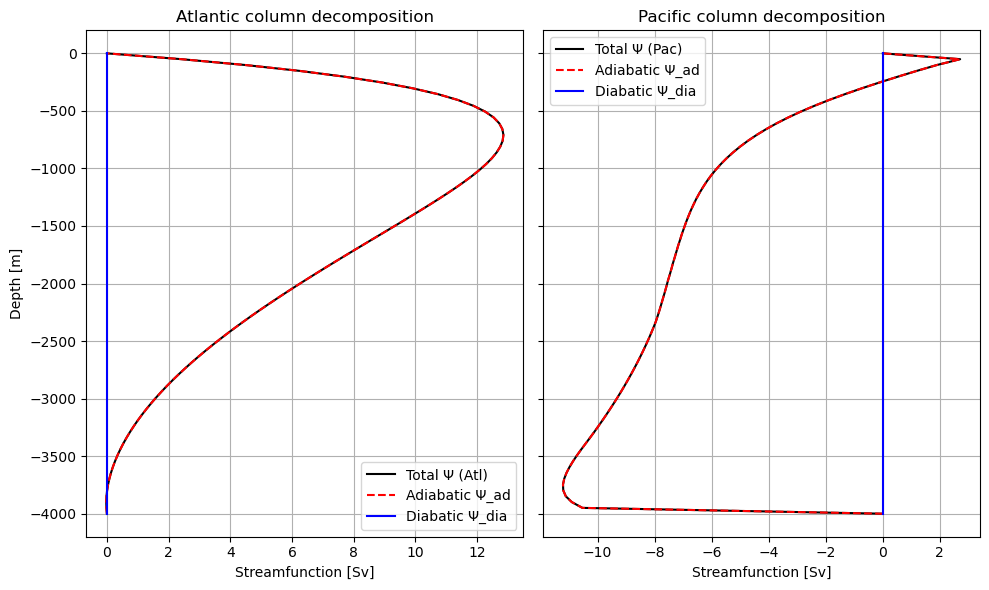

In [36]:
#=============================================================================
# Physically-based adiabatic / diabatic decomposition using diffusive fluxes
#=============================================================================

def compute_diabatic_streamfunction(column, z):
    kappa = column.kappa(z)
    b = column.b
    dbdz = np.gradient(b, z)
    F = -kappa * dbdz                  # vertical buoyancy flux
    dFdz = np.gradient(F, z)           # vertical derivative of flux
    w_dia = dFdz                       # vertical velocity (arbitrary scale)
    Psi_dia = np.cumsum(w_dia[::-1])[::-1] * (z[1]-z[0]) * 1e-6  # convert to Sv-like units
    Psi_dia -= Psi_dia[-1]             # normalise bottom to zero
    return Psi_dia

# compute diabatic streamfunctions for each basin
Psi_dia_Atl = compute_diabatic_streamfunction(Atl, z)
Psi_dia_Pac = compute_diabatic_streamfunction(Pac, z)
Psi_dia_N   = compute_diabatic_streamfunction(north, z)

# compute total overturning magnitudes (e.g. mean of AMOC / ZOC etc.)
Psi_total_Atl = AMOC.Psi
Psi_total_Pac = SO_Pac.Psi + ZOC.Psi
Psi_total_N   = AMOC.Psi

# adiabatic = total - diabatic
Psi_ad_Atl = Psi_total_Atl - Psi_dia_Atl
Psi_ad_Pac = Psi_total_Pac - Psi_dia_Pac

# check magnitudes
print("Atl: max total Ψ =", np.nanmax(np.abs(Psi_total_Atl)))
print("Atl: max diabatic Ψ =", np.nanmax(np.abs(Psi_dia_Atl)))
print("Pac: max total Ψ =", np.nanmax(np.abs(Psi_total_Pac)))
print("Pac: max diabatic Ψ =", np.nanmax(np.abs(Psi_dia_Pac)))

#=============================================================================
# Plot decomposition profiles
#=============================================================================
fig, axs = plt.subplots(1, 2, figsize=(10,6), sharey=True)

axs[0].plot(Psi_total_Atl, z, 'k-', label='Total Ψ (Atl)')
axs[0].plot(Psi_ad_Atl, z, 'r--', label='Adiabatic Ψ_ad')
axs[0].plot(Psi_dia_Atl, z, 'b-', label='Diabatic Ψ_dia')
axs[0].set_title('Atlantic column decomposition')
axs[0].set_xlabel('Streamfunction [Sv]')
axs[0].set_ylabel('Depth [m]')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(Psi_total_Pac, z, 'k-', label='Total Ψ (Pac)')
axs[1].plot(Psi_ad_Pac, z, 'r--', label='Adiabatic Ψ_ad')
axs[1].plot(Psi_dia_Pac, z, 'b-', label='Diabatic Ψ_dia')
axs[1].set_title('Pacific column decomposition')
axs[1].set_xlabel('Streamfunction [Sv]')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()
